# Run the might and other models on the cancer data

In [19]:
# import libraries
import tarfile
import os
import numpy as np
from scipy.stats import multivariate_normal
from scipy.stats import entropy
from sklearn import metrics
from sklearn.metrics import roc_auc_score

# import matplotlib.pyplot as plt
# import seaborn as sns
import pandas as pd
import warnings
import string
warnings.filterwarnings("ignore")

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

from sktree.stats import build_oob_forest
from sktree.ensemble import HonestForestClassifier

import matplotlib.pyplot as plt
import pickle

In [20]:
# load the .tar.gz file
# tarfile.open("./ManuscriptFeatureMatrices.tar.gz", "r:gz").extractall()

# load the data
filelist = os.listdir("./ManuscriptFeatureMatrices")
filelist = [f for f in filelist if f.endswith(".csv")]
# print(filelist)
print(len(filelist))
print(filelist)

# get the sample list
sample_list_file = "./ManuscriptFeatureMatrices/AllSamples.MIGHT.Passed.samples.txt"
sample_list = pd.read_csv(sample_list_file, sep=" ", header=None)
sample_list.columns = ["library", "sample_id", "cohort"]
sample_list.head()
# get the sample_ids where cohort is Cohort1
cohort1 = sample_list[sample_list["cohort"] == "Cohort1"]["sample_id"]
print(cohort1)

44
['Delfi.LengthRatio.csv', 'MotifAnalysis.OutsideTrimer.csv', 'MotifAnalysis.OutsideDimer.csv', 'DyadAccessibility.LINEs.csv', 'LociFraction.cCREFraction.csv', 'MotifAnalysis.InsideMonomer.csv', 'LengthAnalysis.Length20.csv', 'MotifAnalysis.InsideDimer.csv', 'DyadAccessibility.cCRE_CTCF.csv', 'LociFraction.CompartmentFraction.csv', 'LociFraction.LINEsFraction.csv', 'DyadAccessibility.cCRE_DistalEnhancers.csv', 'MotifAnalysis.CongruentTetramer.csv', 'LengthAnalysis.Length5.csv', 'MotifAnalysis.OutsideTetramer.csv', 'WiseCondorX.Wise-5.csv', 'MotifAnalysis.InsidePentamer.csv', 'MotifAnalysis.CongruentHexamer.csv', 'DyadAccessibility.AluS.csv', 'WiseCondorX.Wise-1.csv', 'MotifAnalysis.OutsideMonomer.csv', 'LengthAnalysis.Length1.csv', 'WiseCondorX.Wise-10.csv', 'MotifAnalysis.InsideHexamer.csv', 'MotifAnalysis.InsideTetramer.csv', 'MotifAnalysis.InsideTrimer.csv', 'DyadAccessibility.AluJ.csv', 'MotifAnalysis.OutsidePentamer.csv', 'MotifAnalysis.CongruentDimer.csv', 'MotifAnalysis.Degene

In [21]:
# define a function to get X and y given a file

def get_X_y(f, root="./ManuscriptFeatureMatrices/", cohort=cohort1, dropnans=True, verbose=False):
    df = pd.read_csv(root + f)
    non_features = ['Run', 'Sample', 'Library', 'Cancer Status', 'Tumor type', 'Stage', 'Library volume (uL)', 'Library Volume', 'UIDs Used', 'Experiment', 'P7', 'P7 Primer', 'MAF']
    sample_ids = df["Sample"]
    # if sample is contains "Run" column, remove it
    for i, sample_id in enumerate(sample_ids):
        if "." in sample_id:
            sample_ids[i] = sample_id.split(".")[1]
    target = 'Cancer Status'
    y = df[target]
    # convert the labels to 0 and 1
    y = y.replace("Healthy", 0)
    y = y.replace("Cancer", 1)
    # remove the non-feature columns if they exist
    for col in non_features:
        if col in df.columns:
            df = df.drop(col, axis=1)
    nan_cols = df.isnull().all(axis=0).to_numpy()
    # drop the columns with all nan values
    df = df.loc[:, ~nan_cols]
    # if cohort is not None, filter the samples
    if cohort is not None:
        # filter the rows with cohort1 samples
        X = df[sample_ids.isin(cohort)]
        y = y[sample_ids.isin(cohort)]
    else:
        X = df
    # impute the nan values with the mean of the column
    # X = X.fillna(X.mean())
    # drop the rows with nan values
    nan_col = X.isnull().any(axis=0)
    if dropnans:
        X = X.fillna(X.mean())
        # y = y[-nan_rows]
    if verbose:
        print(f"X shape: {X.shape}")
        print(f"y shape: {y.shape}")
    return X, y


In [22]:
from math import nan


X, y = get_X_y(filelist[19], cohort=cohort1, verbose=True, dropnans=False)
nan_rows = X.isnull().any(axis=1)
nan_rows.sum()

X shape: (352, 2523)
y shape: (352,)


352

In [6]:
# X, y = get_X_y(filelist[0])

# n_jobs = 10
# seed = 42
# sample_size = X.shape[0]

# lr = LogisticRegression(
#     penalty="l1", solver="liblinear", n_jobs=n_jobs, random_state=seed
# )
# gnb = GaussianNB()
# #     svc = NaivelyCalibratedLinearSVC(C=1.0)
# svc = SVC(probability=True, kernel="rbf", random_state=seed)
# rfc = RandomForestClassifier(
#     n_estimators=6000, max_features=0.3, n_jobs=n_jobs, random_state=seed
# )
# might = HonestForestClassifier(
#     n_estimators=6000,
#     max_samples=1.6,
#     max_features=0.3,
#     bootstrap=True,
#     stratify=True,
#     random_state=seed,
#     n_jobs=n_jobs,
# )

# clf_list = [
#     (might, "MIGHT"),
#     (rfc, "Random Forest"),
#     (svc, "SVM"),
#     (gnb, "Naive Bayes"),
#     (lr, "Logistic Regression"),
# ]

# fpr_s = []
# tpr_s = []
# for i, (clf, name) in enumerate(clf_list):
#     if name == "MIGHT":
#         _, observe_proba = build_hyppo_oob_forest(clf, X, y)
#         observe_proba = np.nanmean(observe_proba, axis=0)
#         fpr, tpr, thresholds = roc_curve(
#             y, observe_proba[:, 1], pos_label=1, drop_intermediate=False
#         )
#     else:
#         X_train, X_test, y_train, y_test = train_test_split(
#             X, y, shuffle=True, stratify=y, test_size=0.2
#         )

#         X_fit, X_cal, y_fit, y_cal = train_test_split(
#             X_train, y_train, test_size=0.5, stratify=y_train
#         )
#         clf.fit(X_fit, y_fit)

#         if X_cal.shape[0] <= 1024:
#             calibrated_model = CalibratedClassifierCV(
#                 clf, cv="prefit", method="sigmoid"
#             )
#         else:
#             calibrated_model = CalibratedClassifierCV(
#                 clf, cv="prefit", method="isotonic"
#             )
#         calibrated_model.fit(X_cal, y_cal)
#         posterior = calibrated_model.predict_proba(X_test)

#         fpr, tpr, thresholds = roc_curve(
#             y_test,
#             posterior[:, 1],
#             pos_label=1,
#             drop_intermediate=False,
#         )
#     fpr_s.append(fpr)
#     tpr_s.append(tpr)

In [25]:
def run_models(filename, seed=23, n_jobs=-5, root="./ManuscriptFeatureMatrices/", cohort=cohort1, verbose=False):
    # get the data
    X, y = get_X_y(filename, root=root, cohort=cohort, verbose=verbose)

    lr = LogisticRegression(
        penalty="l2", solver="liblinear", n_jobs=n_jobs, random_state=seed
    )
    gnb = GaussianNB()
    #     svc = NaivelyCalibratedLinearSVC(C=1.0)
    svc = SVC(probability=True, kernel="rbf", random_state=seed)
    rfc = RandomForestClassifier(
        n_estimators=6000, max_features=0.3, n_jobs=n_jobs, random_state=seed
    )
    might = HonestForestClassifier(
        n_estimators=6000,
        max_samples=1.6,
        max_features=0.3,
        bootstrap=True,
        stratify=True,
        random_state=seed,
        n_jobs=n_jobs,
        honest_prior="ignore"
    )

    clf_list = [
        (might, "MIGHT"),
        (rfc, "Random Forest"),
        (svc, "SVM"),
        (gnb, "Naive Bayes"),
        (lr, "Logistic Regression"),
    ]

    fpr_s = []
    tpr_s = []
    for i, (clf, name) in enumerate(clf_list):
        if name == "MIGHT":
            _, observe_proba = build_oob_forest(clf, X, y)
            observe_proba = np.nanmean(observe_proba, axis=0)
            fpr, tpr, thresholds = roc_curve(
                y, observe_proba[:, 1], pos_label=1, drop_intermediate=False
            )
        else:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, shuffle=True, stratify=y, test_size=0.2
            )

            X_fit, X_cal, y_fit, y_cal = train_test_split(
                X_train, y_train, test_size=0.5, stratify=y_train
            )
            clf.fit(X_fit, y_fit)

            if X_cal.shape[0] <= 1024:
                calibrated_model = CalibratedClassifierCV(
                    clf, cv="prefit", method="sigmoid"
                )
            else:
                calibrated_model = CalibratedClassifierCV(
                    clf, cv="prefit", method="isotonic"
                )
            calibrated_model.fit(X_cal, y_cal)
            posterior = calibrated_model.predict_proba(X_test)

            fpr, tpr, thresholds = roc_curve(
                y_test,
                posterior[:, 1],
                pos_label=1,
                drop_intermediate=False,
            )
        fpr_s.append(fpr)
        tpr_s.append(tpr)

    return clf_list, fpr_s, tpr_s

In [26]:
import pickle
from tabnanny import verbose

# clfs = []
# fprs = []
# tprs = []

N_ITR = 1
N_JOBS = -5
DIRECTORY = "./results/"
VERSION = 1
# create files to store the results if they don't exist
save_files = [DIRECTORY + f + f"_{N_ITR}_{VERSION}.pkl" for f in ["fprs", "tprs", "clfs"]]
for f in save_files:
    if not os.path.exists(f):
        with open(f, "wb") as f:
            pickle.dump([], f)

start = 0
end = len(filelist)

for i in range(N_ITR):
    print(i)
    # open the files to append the results
    with open(DIRECTORY + f"fprs_{N_ITR}_{VERSION}.pkl", "rb") as f:
        fprs = pickle.load(f)
    with open(DIRECTORY + f"tprs_{N_ITR}_{VERSION}.pkl", "rb") as f:
        tprs = pickle.load(f)
    with open(DIRECTORY + f"clfs_{N_ITR}_{VERSION}.pkl", "rb") as f:
        clfs = pickle.load(f)
    for file in filelist[start:end]:
        print(file)
        clf_list, fpr_s, tpr_s = run_models(file, seed=i, n_jobs=N_JOBS, cohort=cohort1)
        clfs.append(clf_list)
        fprs.append(fpr_s)
        tprs.append(tpr_s)

        # save the results
        with open(DIRECTORY + f"fprs_{N_ITR}_{VERSION}.pkl", "wb") as f:
            pickle.dump(fprs, f)

        with open(DIRECTORY + f"tprs_{N_ITR}_{VERSION}.pkl", "wb") as f:
            pickle.dump(tprs, f)

        with open(DIRECTORY + f"clfs_{N_ITR}_{VERSION}.pkl", "wb") as f:
            pickle.dump(clfs, f)


0
Delfi.LengthRatio.csv
MotifAnalysis.OutsideTrimer.csv
MotifAnalysis.OutsideDimer.csv
DyadAccessibility.LINEs.csv
LociFraction.cCREFraction.csv
MotifAnalysis.InsideMonomer.csv
LengthAnalysis.Length20.csv
MotifAnalysis.InsideDimer.csv
DyadAccessibility.cCRE_CTCF.csv
LociFraction.CompartmentFraction.csv
LociFraction.LINEsFraction.csv
DyadAccessibility.cCRE_DistalEnhancers.csv
MotifAnalysis.CongruentTetramer.csv
LengthAnalysis.Length5.csv
MotifAnalysis.OutsideTetramer.csv
WiseCondorX.Wise-5.csv
MotifAnalysis.InsidePentamer.csv
MotifAnalysis.CongruentHexamer.csv
DyadAccessibility.AluS.csv
WiseCondorX.Wise-1.csv


ValueError: Input X contains NaN.
HonestForestClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [9]:
DIRECTORY = "./results/"
N_ITR = 5
VERSION = 1
# with open(DIRECTORY + "clfs.pkl", "rb") as f:
#     clfs = pickle.load(f)
with open(DIRECTORY + f"fprs_{N_ITR}_{VERSION}.pkl", "rb") as f:
    fprs = pickle.load(f)
with open(DIRECTORY + f"tprs_{N_ITR}_{VERSION}.pkl", "rb") as f:
    tprs = pickle.load(f)

print(len(fprs))
print(len(tprs))


20
20


In [17]:
len(fprs[0][2])

TypeError: object of type 'numpy.float64' has no len()

Delfi.LengthRatio
MotifAnalysis.OutsideTrimer
MotifAnalysis.OutsideDimer
DyadAccessibility.LINEs
LociFraction.cCREFraction
MotifAnalysis.InsideMonomer
LengthAnalysis.Length20
MotifAnalysis.InsideDimer
DyadAccessibility.cCRE_CTCF
LociFraction.CompartmentFraction
LociFraction.LINEsFraction
DyadAccessibility.cCRE_DistalEnhancers
MotifAnalysis.CongruentTetramer
LengthAnalysis.Length5
MotifAnalysis.OutsideTetramer
WiseCondorX.Wise-5
MotifAnalysis.InsidePentamer
MotifAnalysis.CongruentHexamer
DyadAccessibility.AluS
WiseCondorX.Wise-1
MotifAnalysis.OutsideMonomer
LengthAnalysis.Length1
WiseCondorX.Wise-10
MotifAnalysis.InsideHexamer
MotifAnalysis.InsideTetramer
MotifAnalysis.InsideTrimer
DyadAccessibility.AluJ
MotifAnalysis.OutsidePentamer
MotifAnalysis.CongruentDimer
MotifAnalysis.DegenerateTetramer
ichorCNA.ichorCNA
DyadAccessibility.BudhrajaRPR
DyadAccessibility.cCRE_Promoters
DyadAccessibility.AluY
DyadAccessibility.L1
DyadAccessibility.cCRE_DNaseH3K4me3
MotifAnalysis.InsideTrimer0.05
Mot

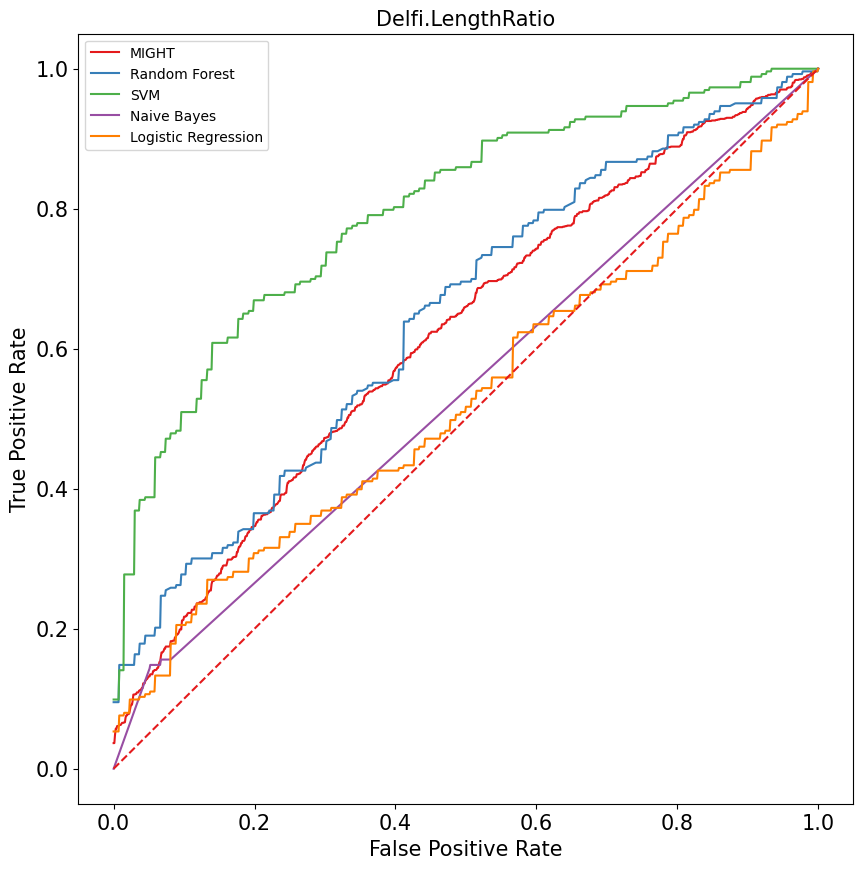

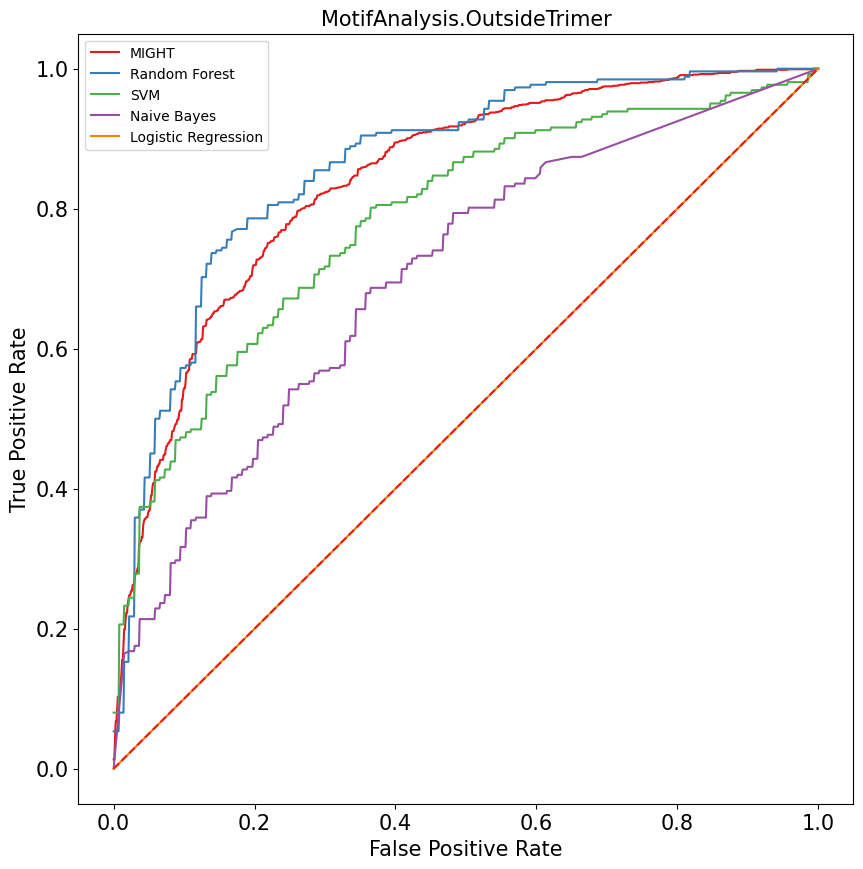

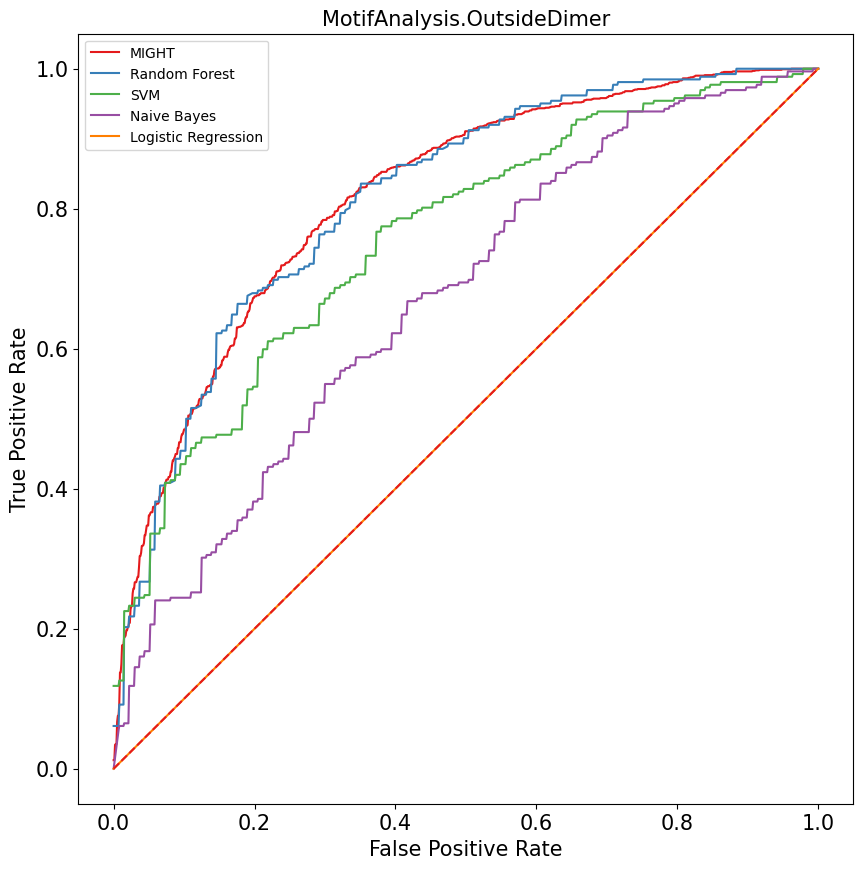

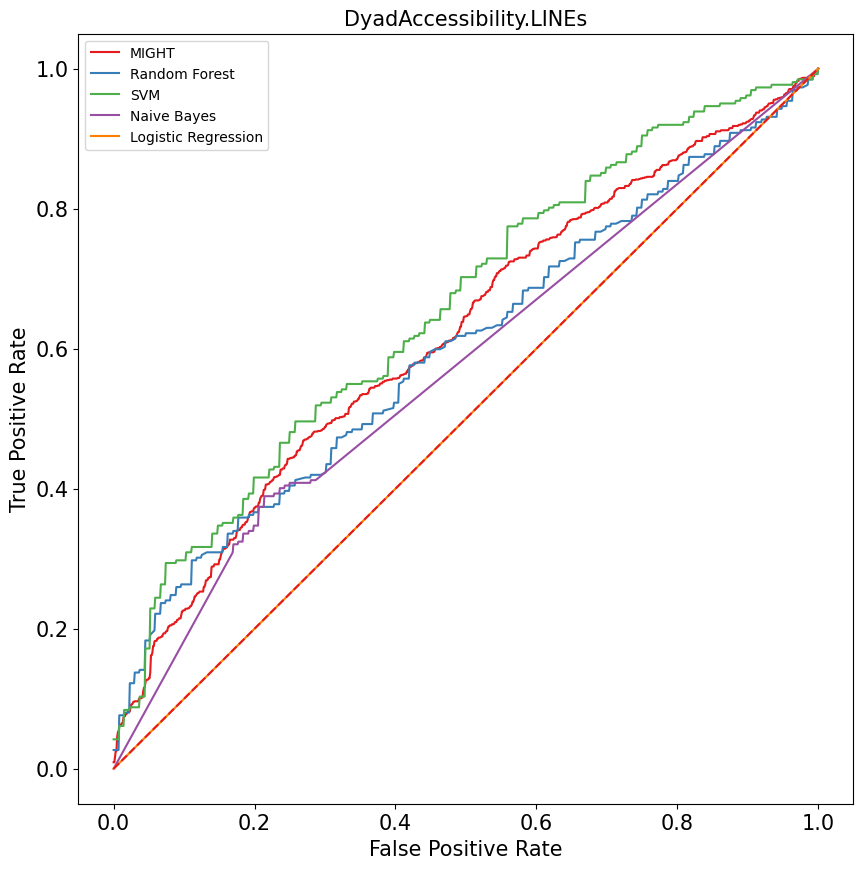

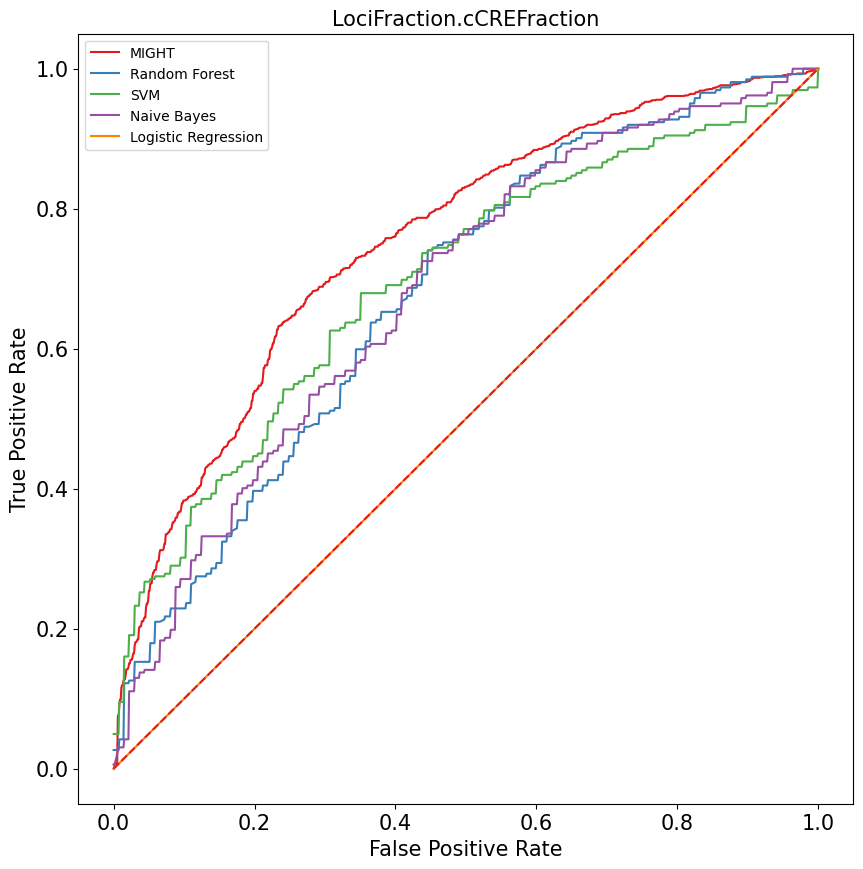

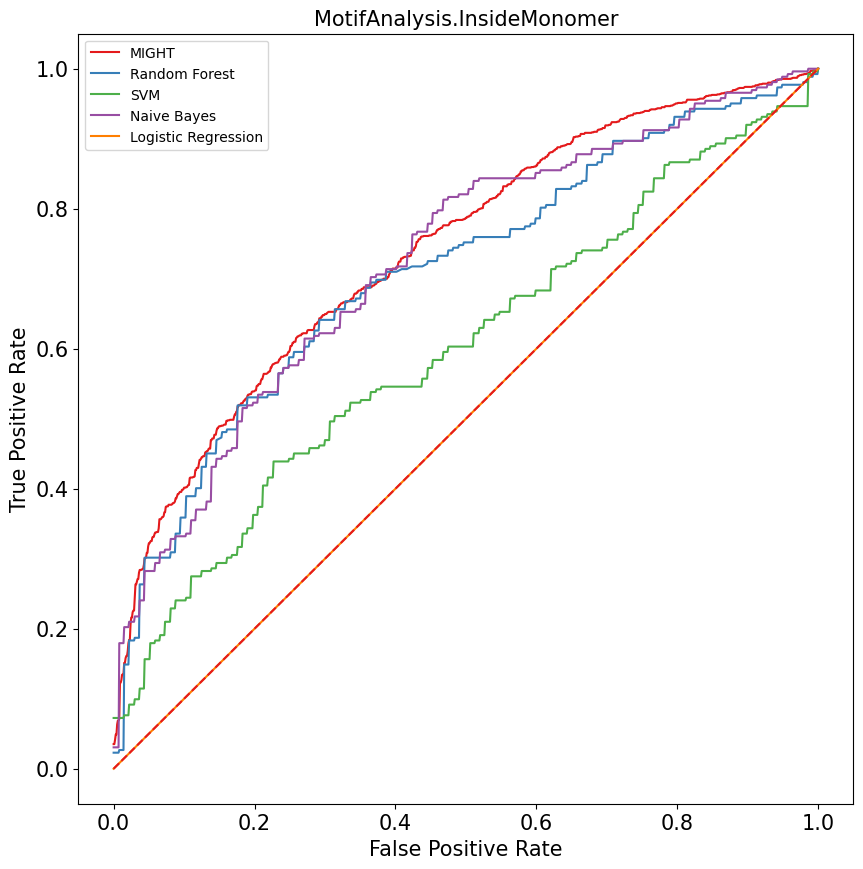

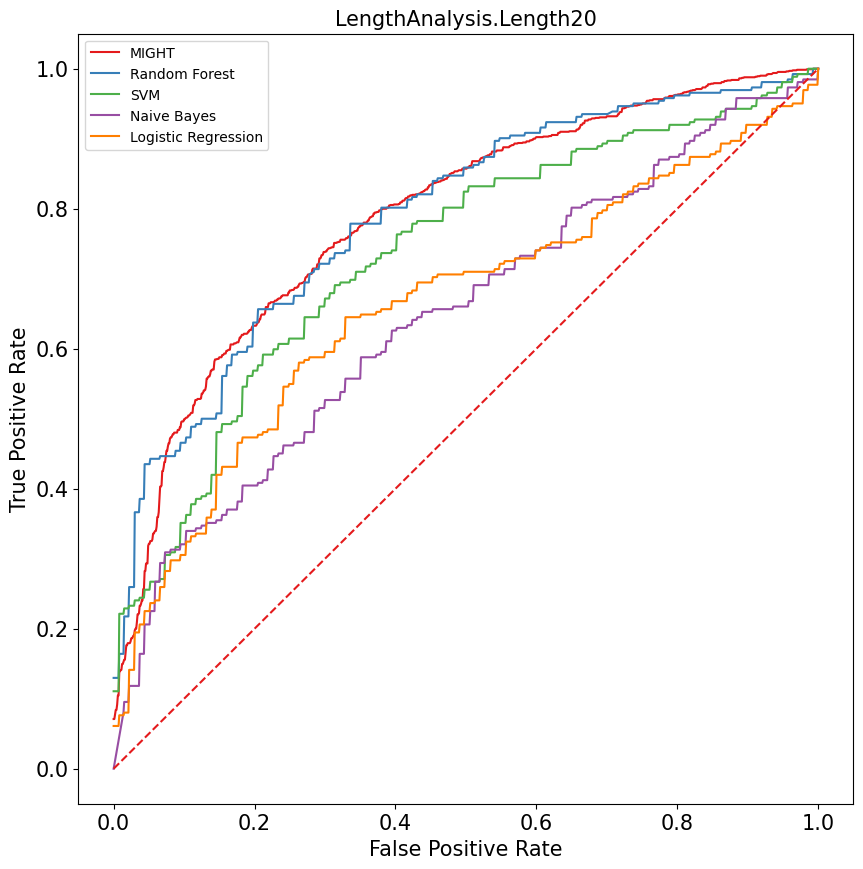

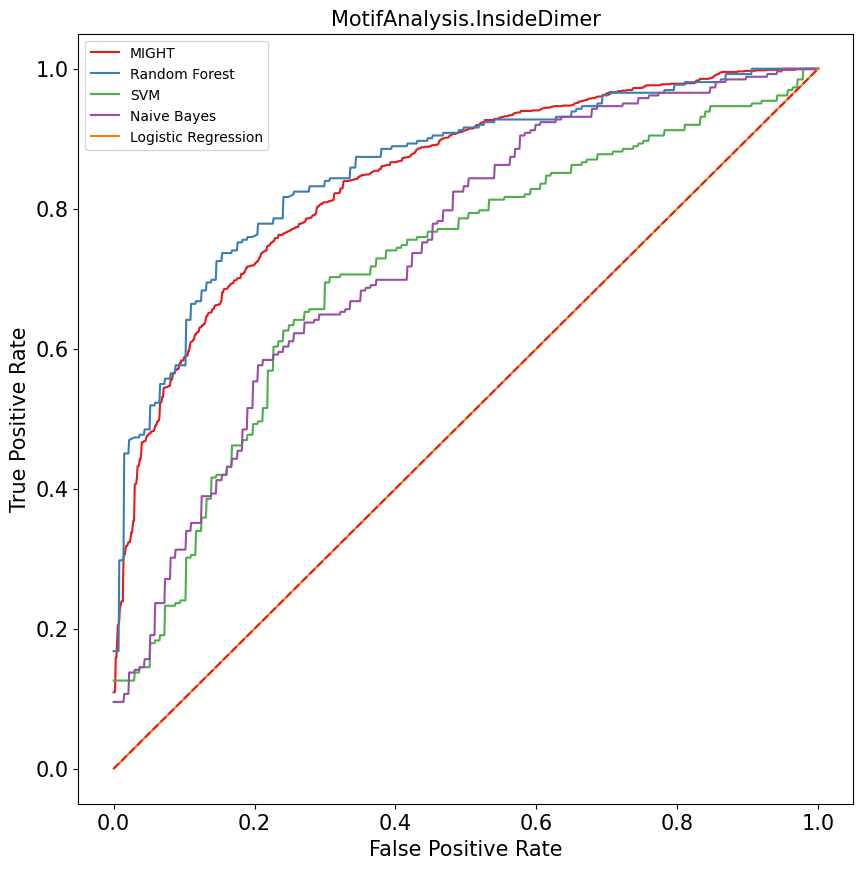

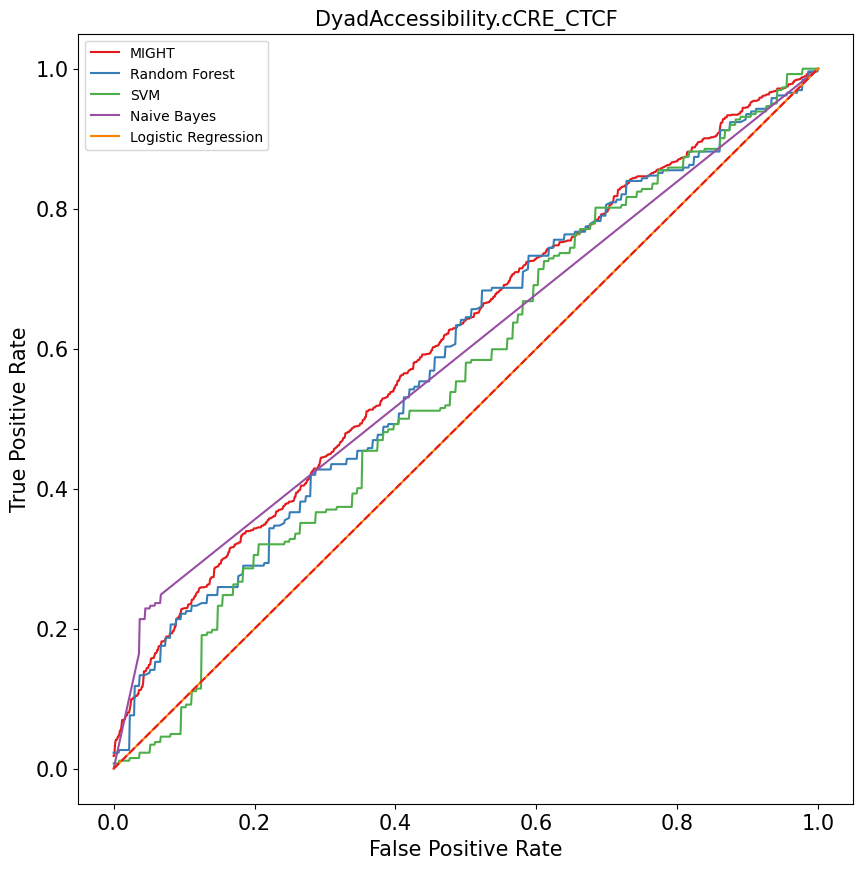

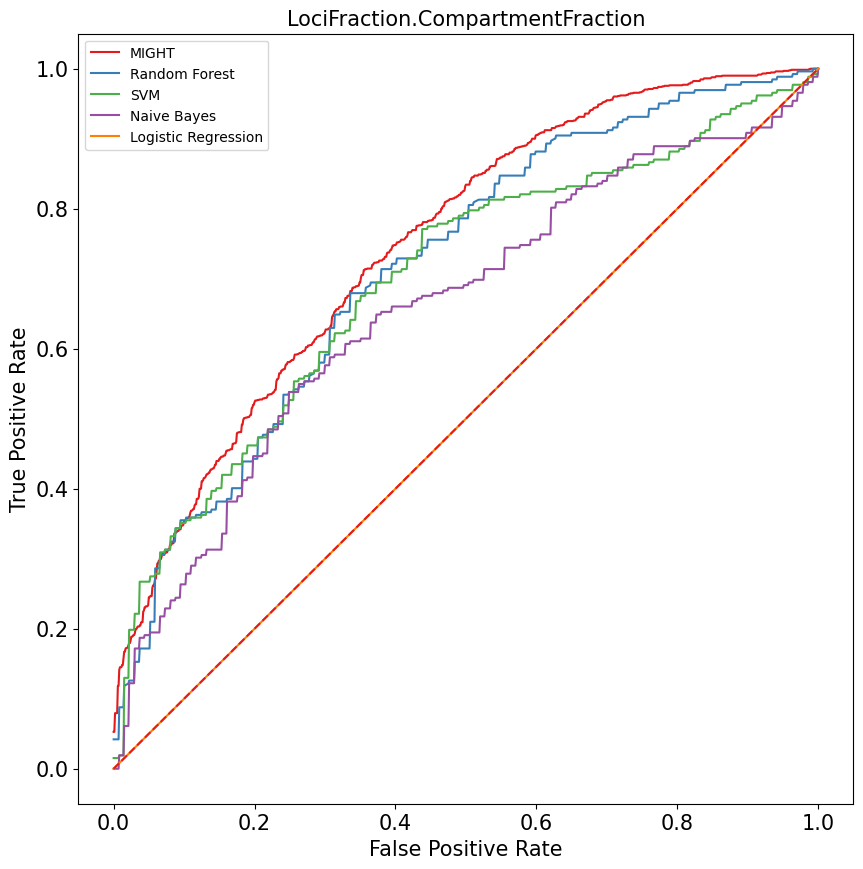

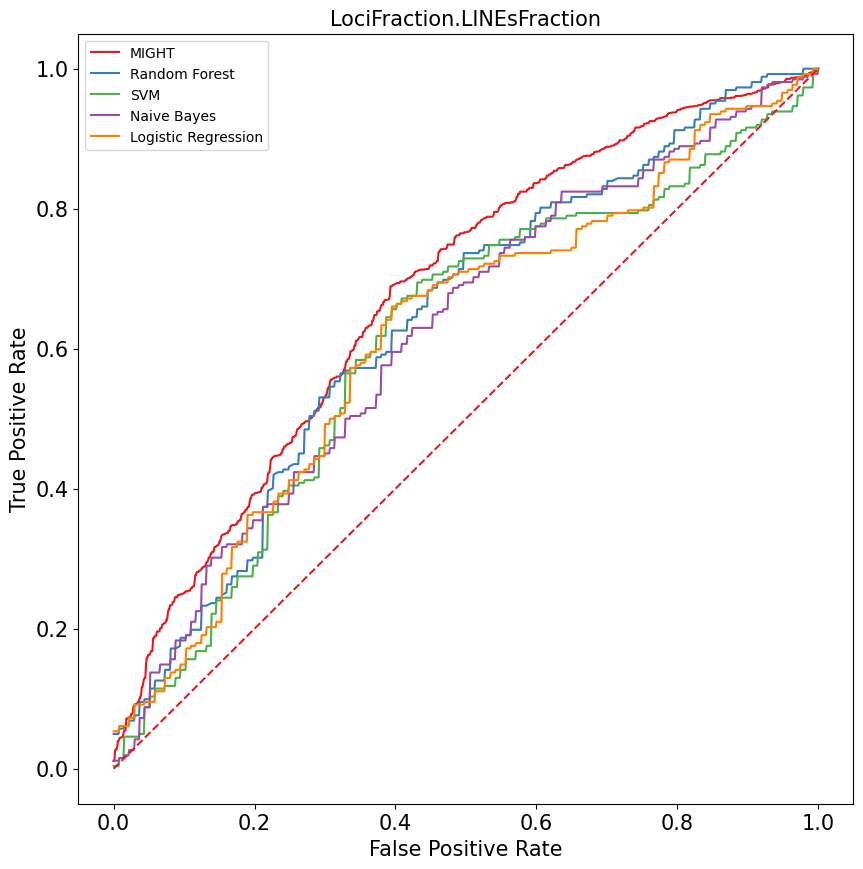

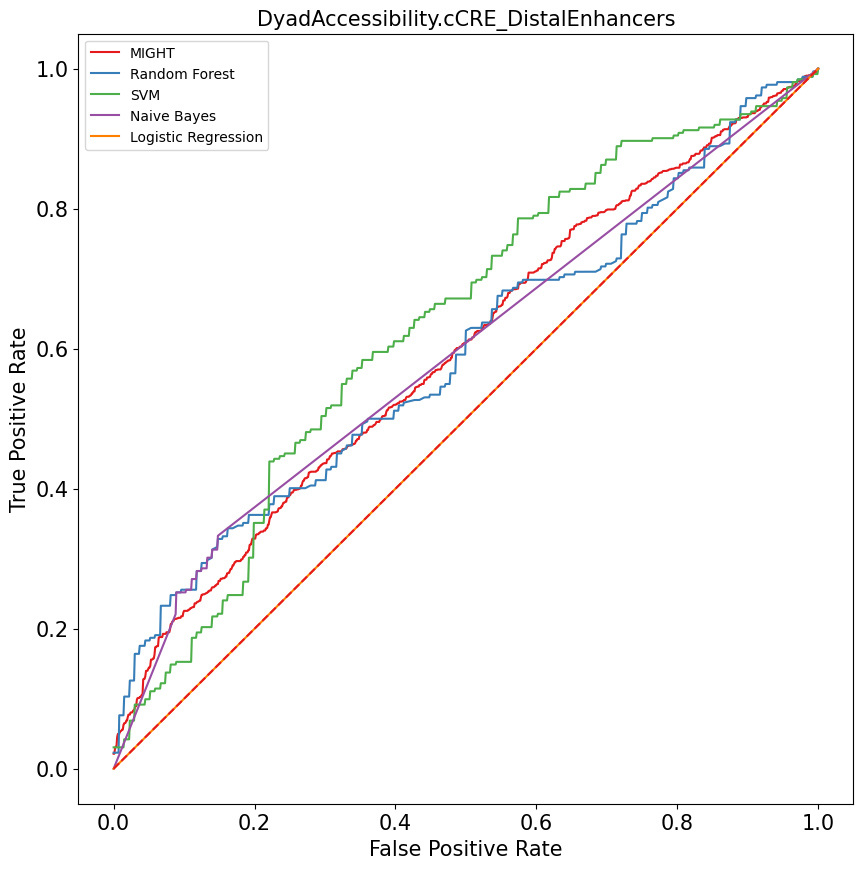

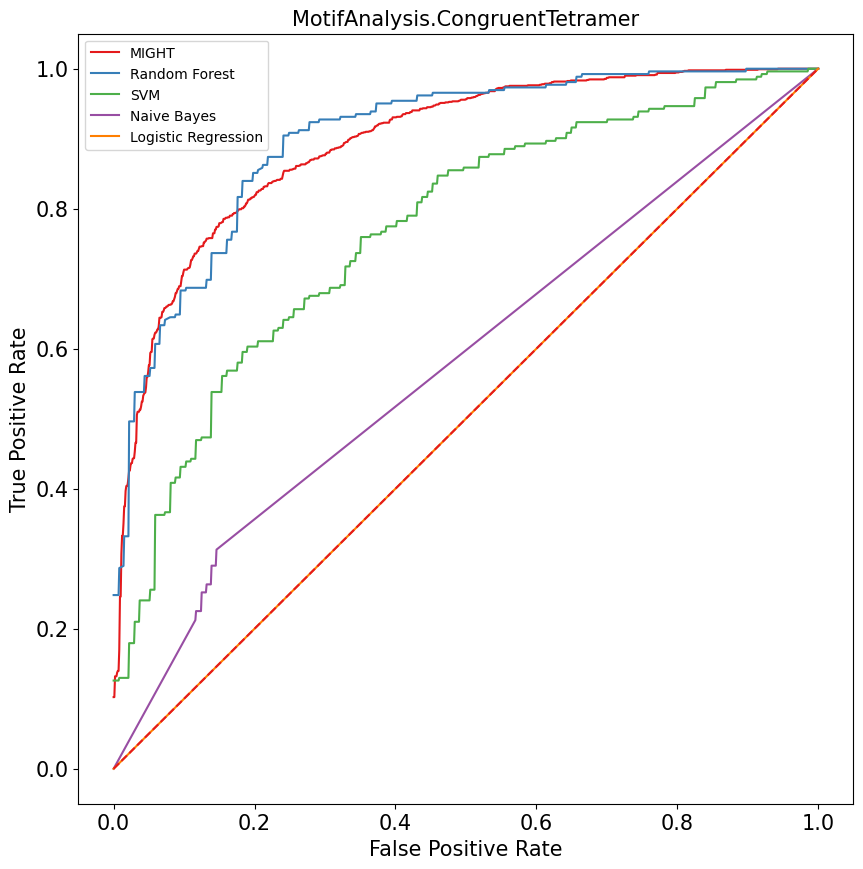

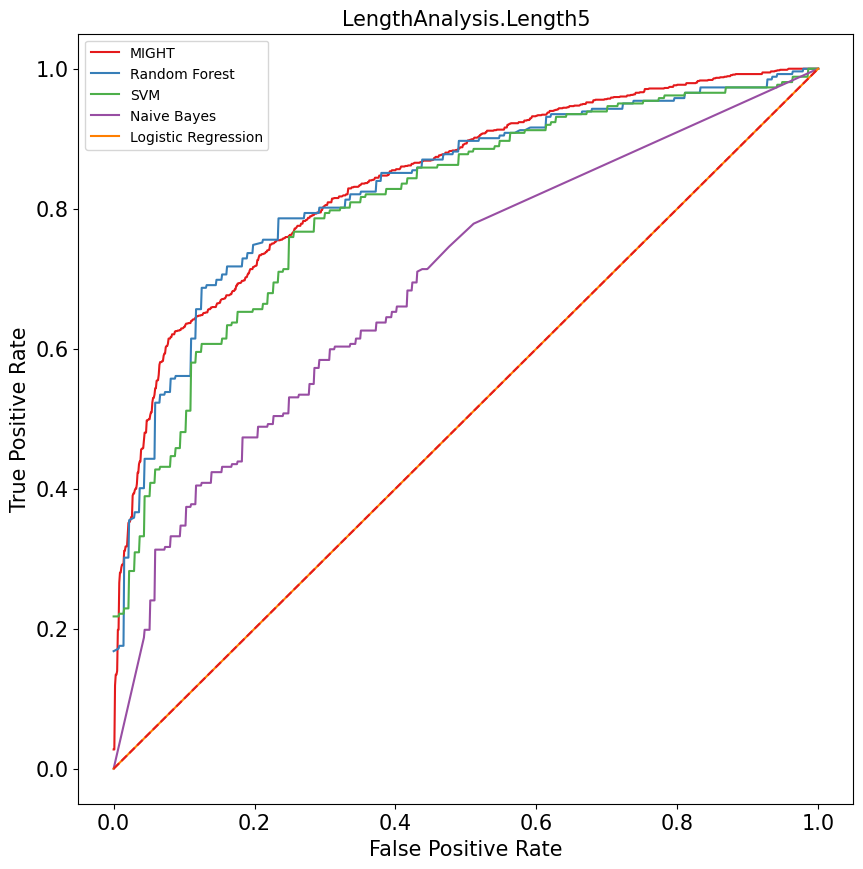

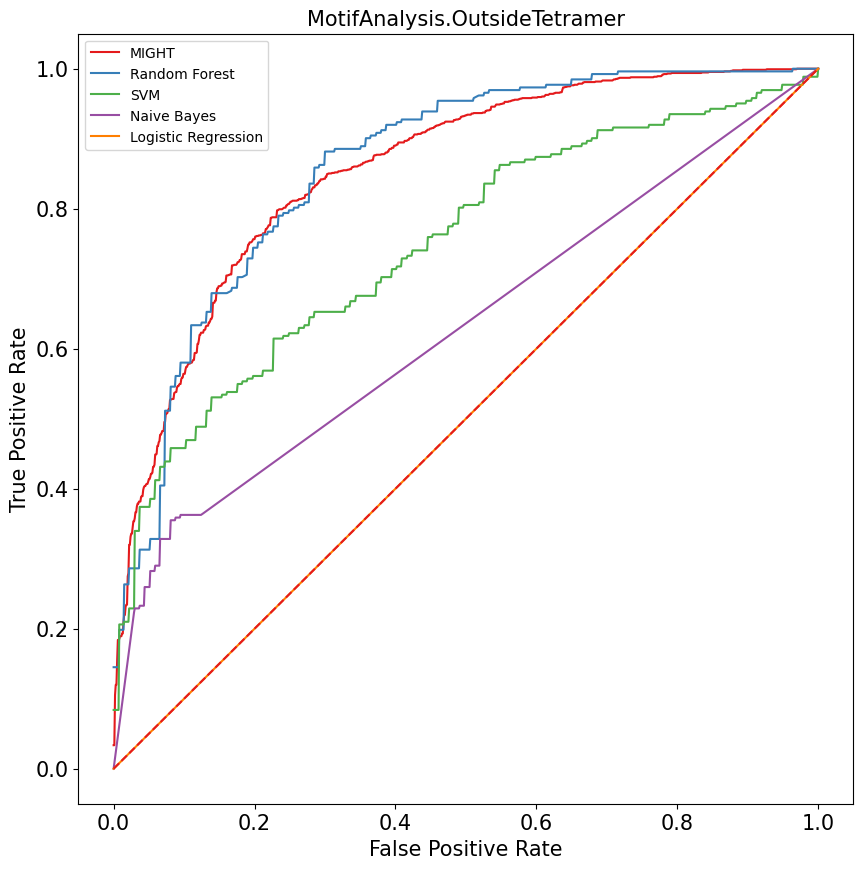

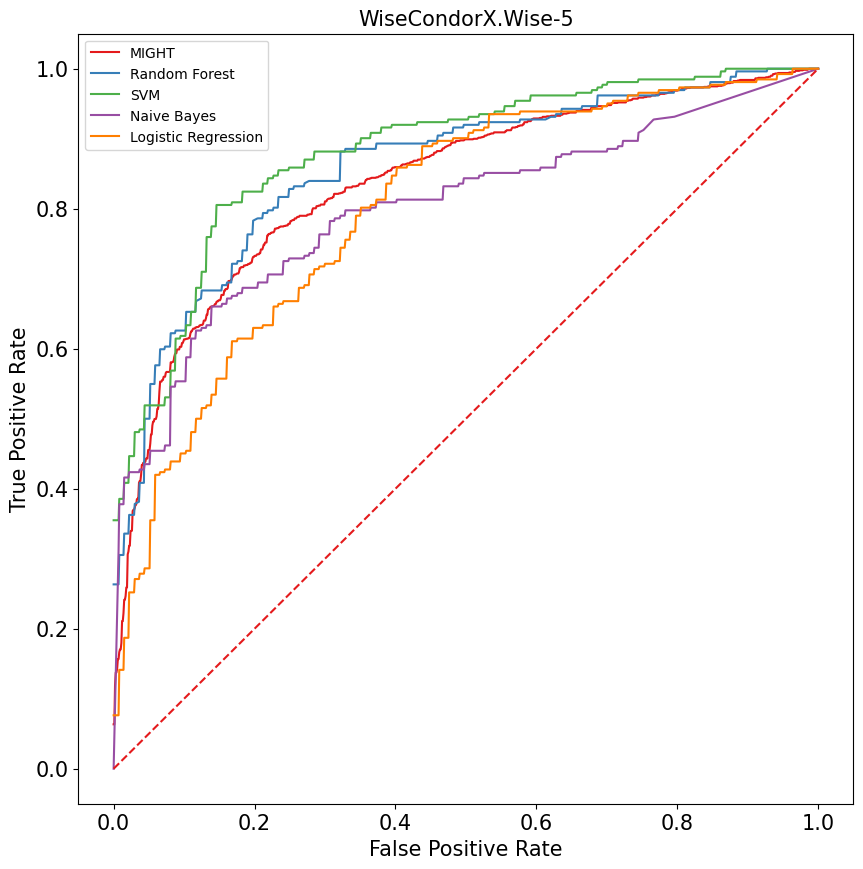

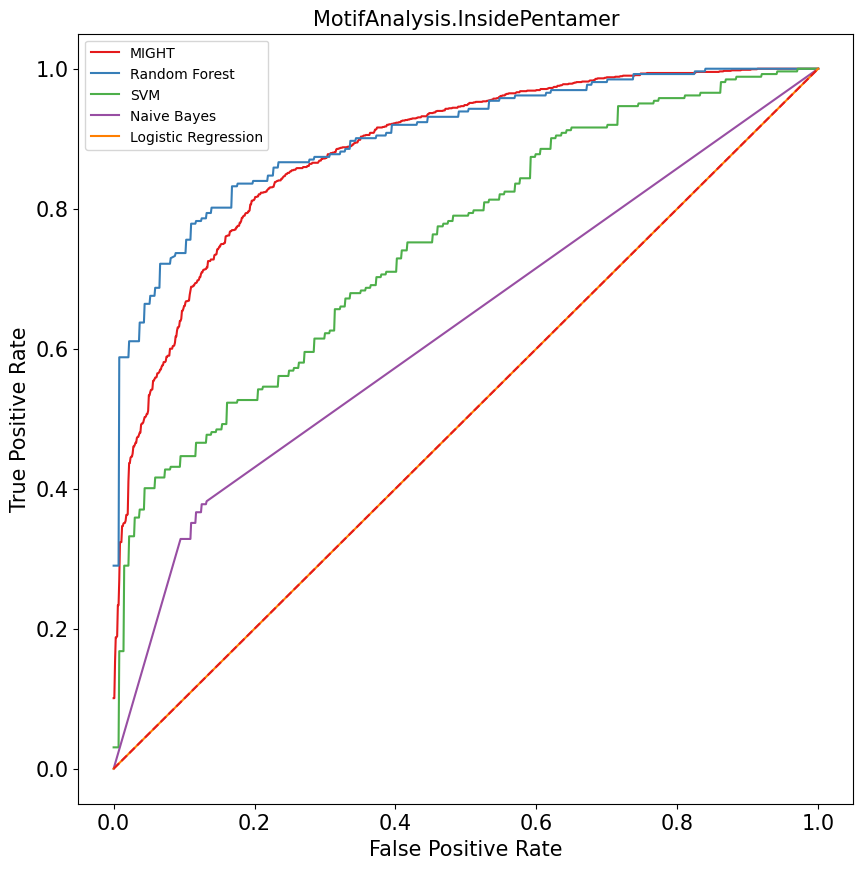

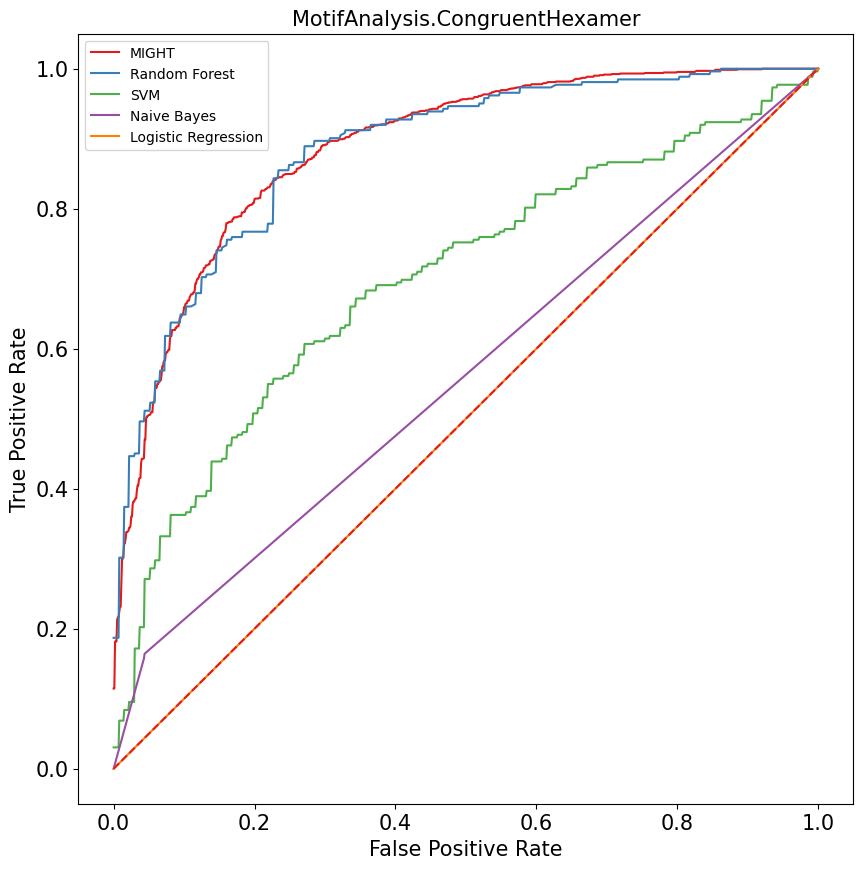

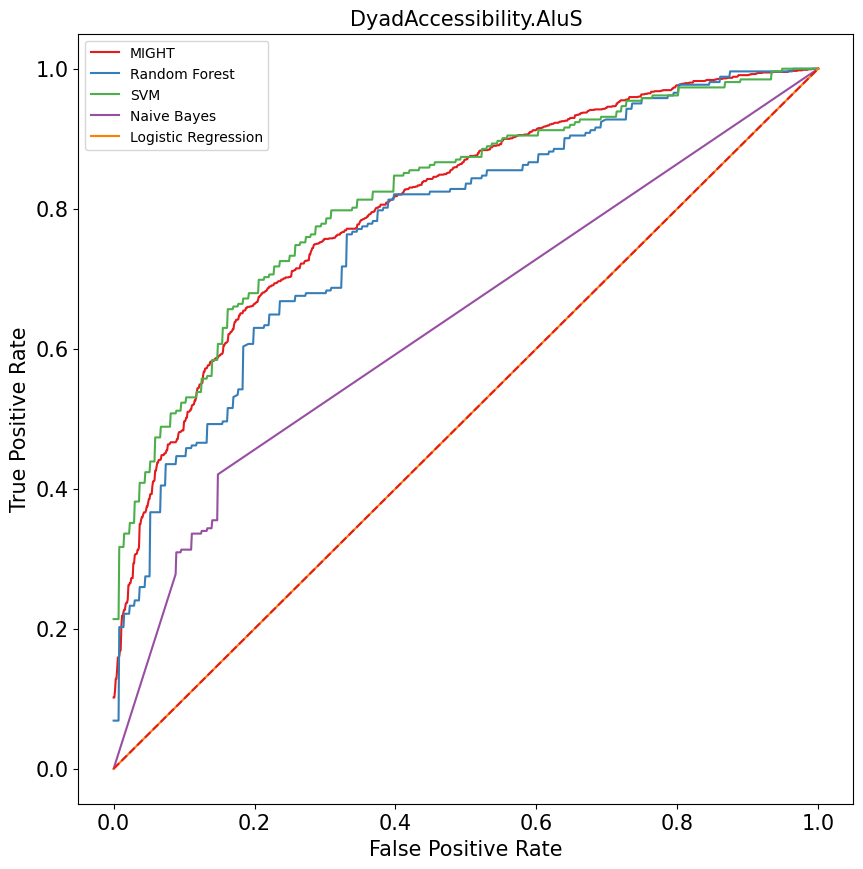

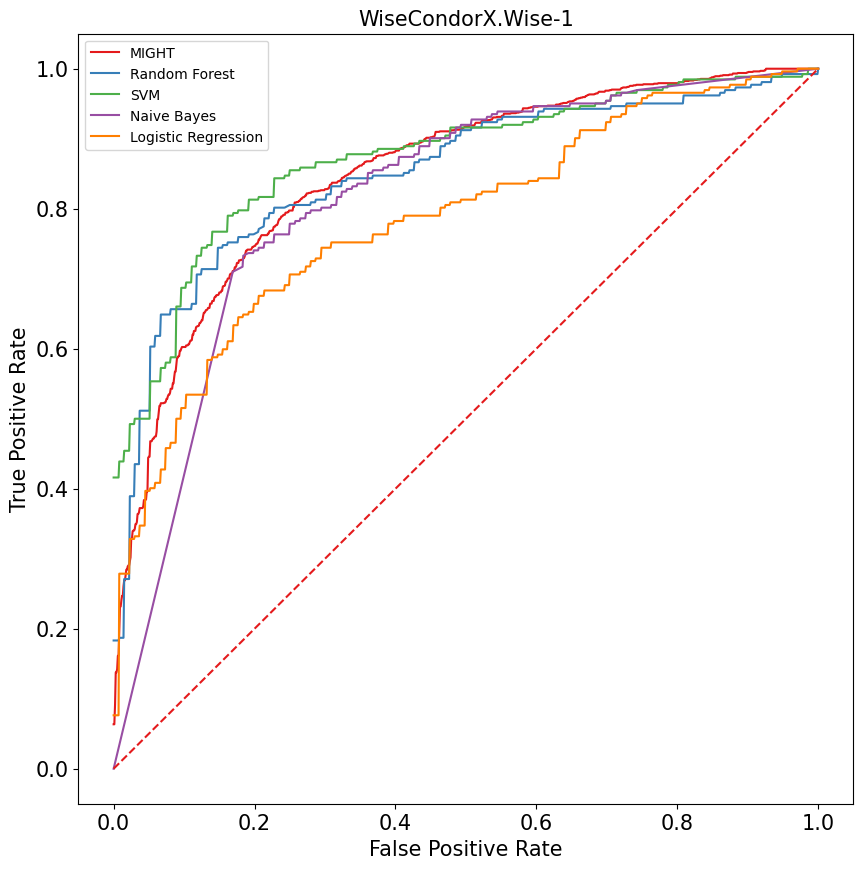

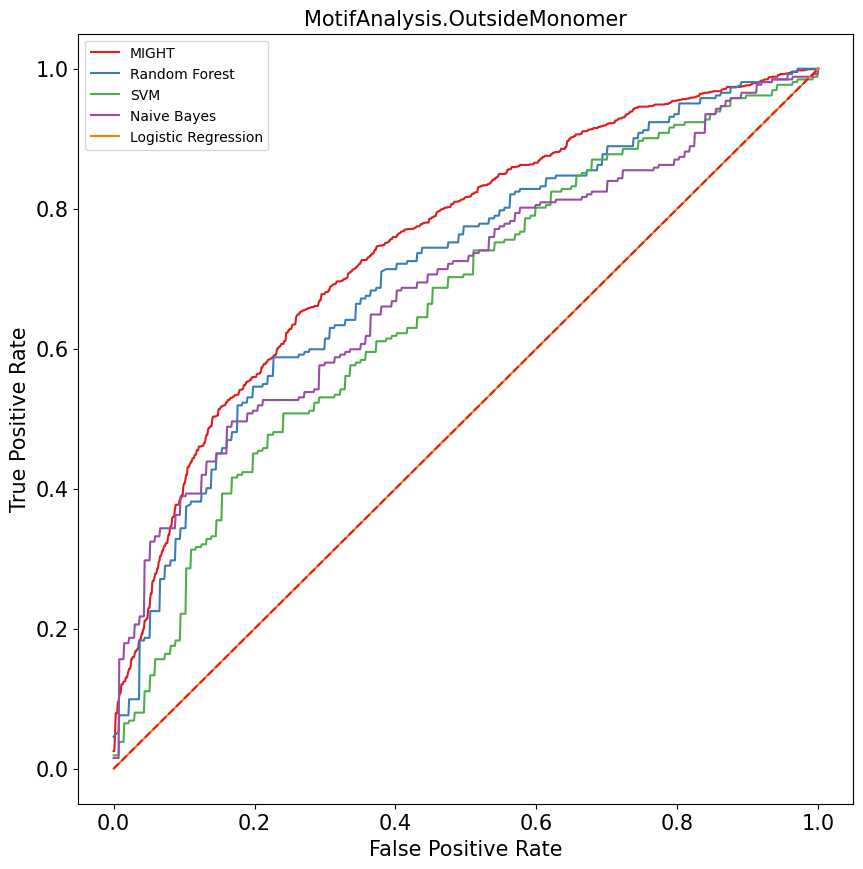

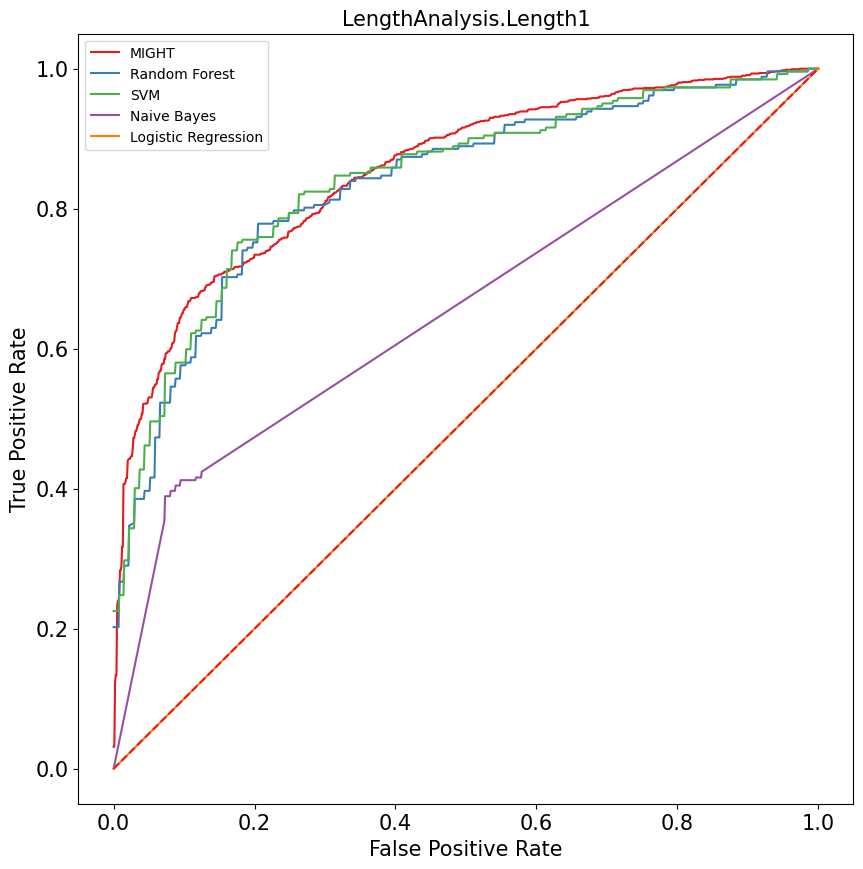

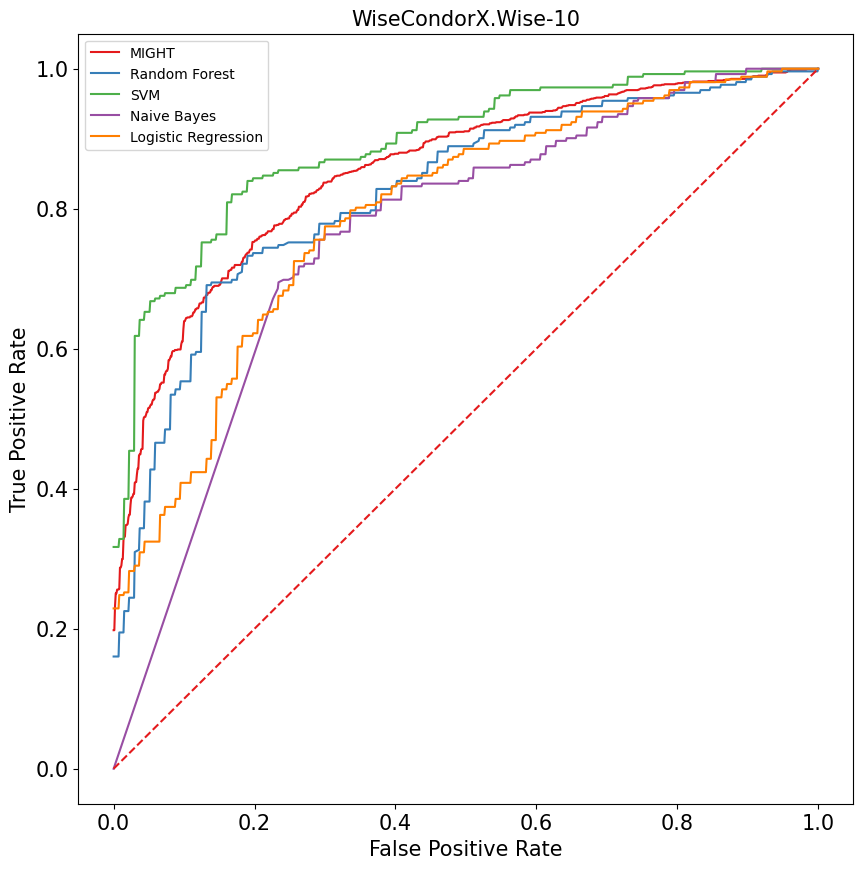

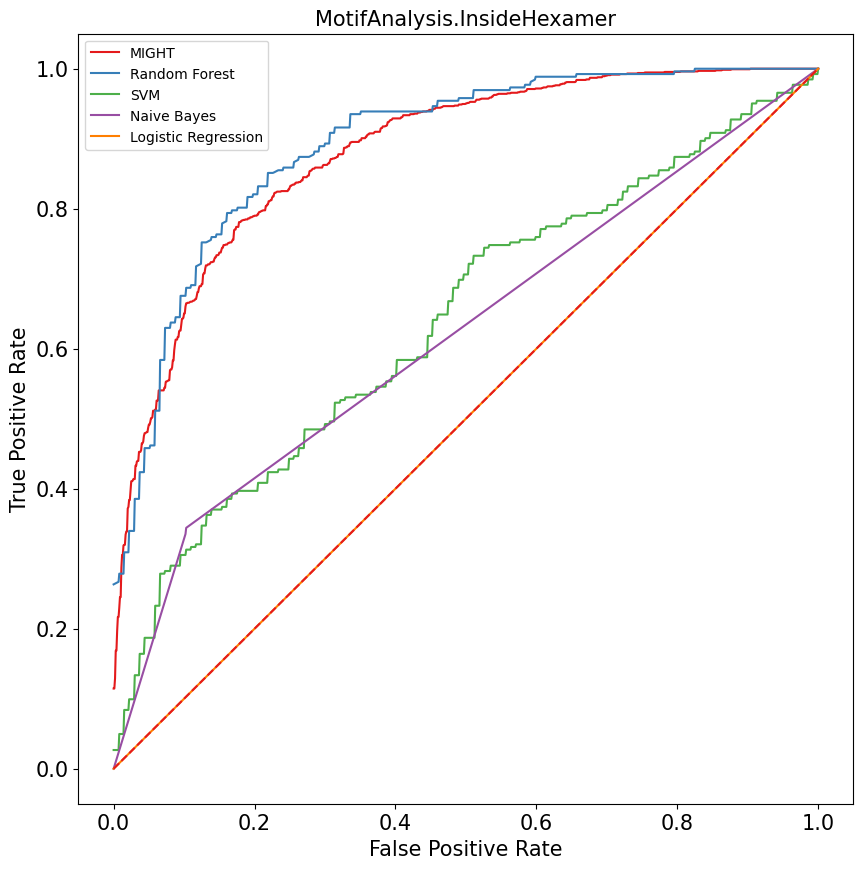

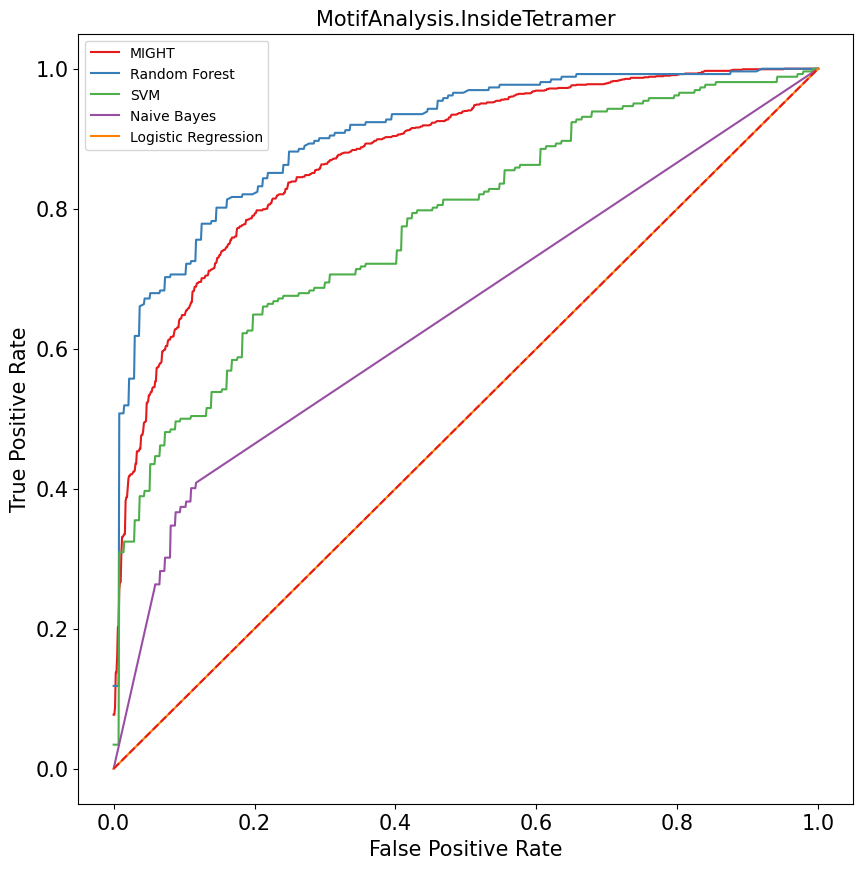

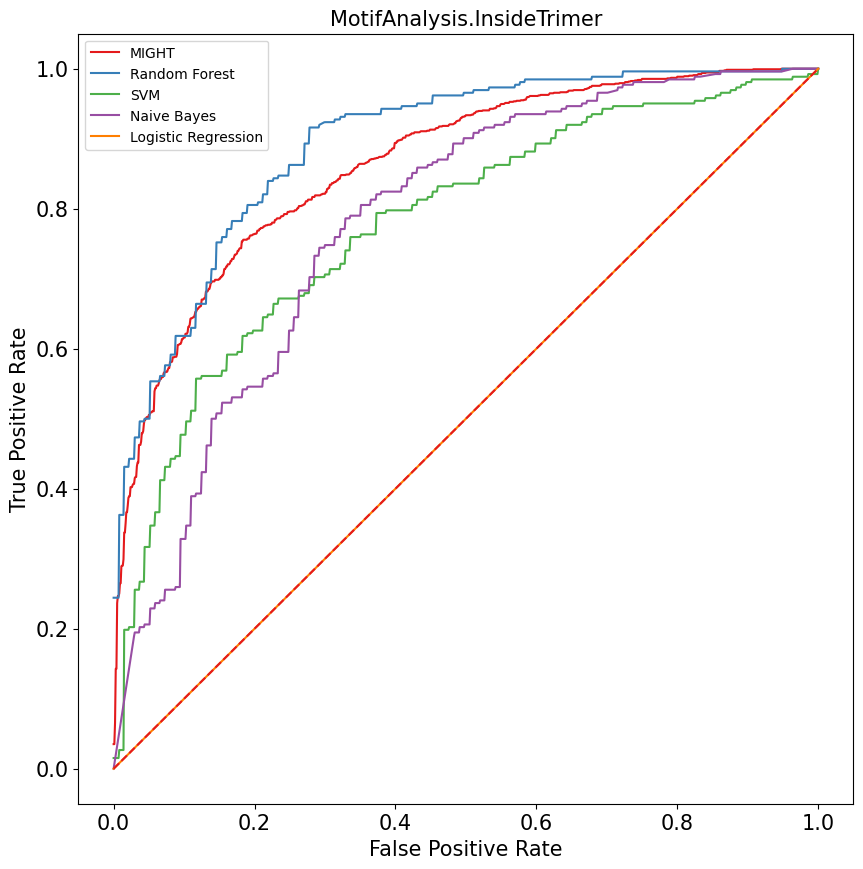

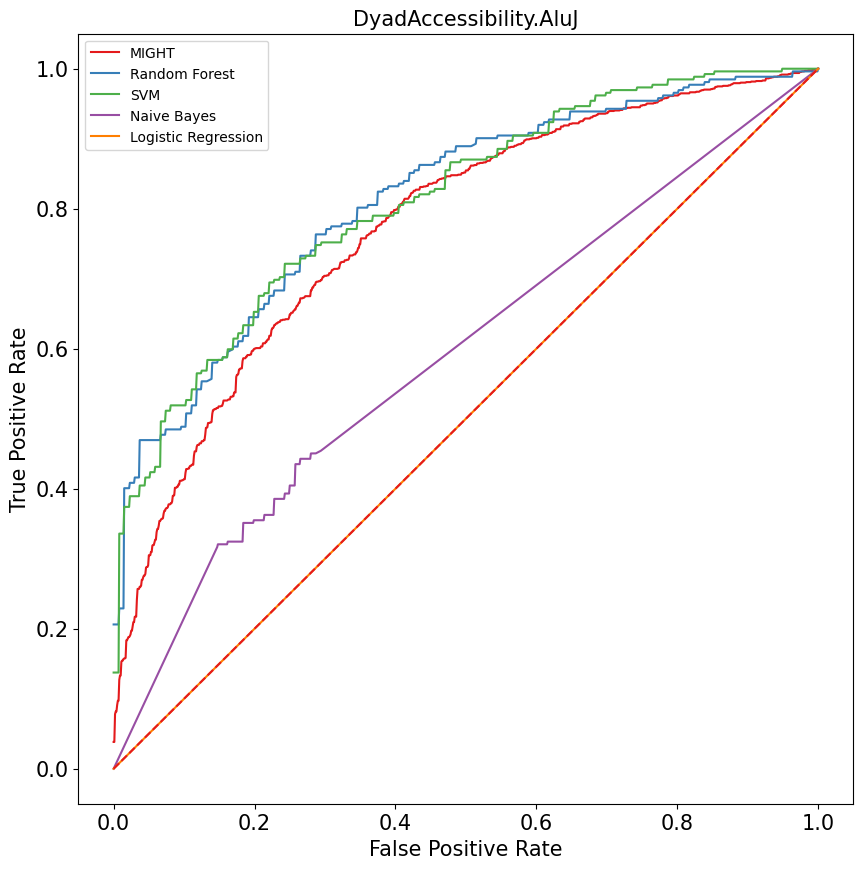

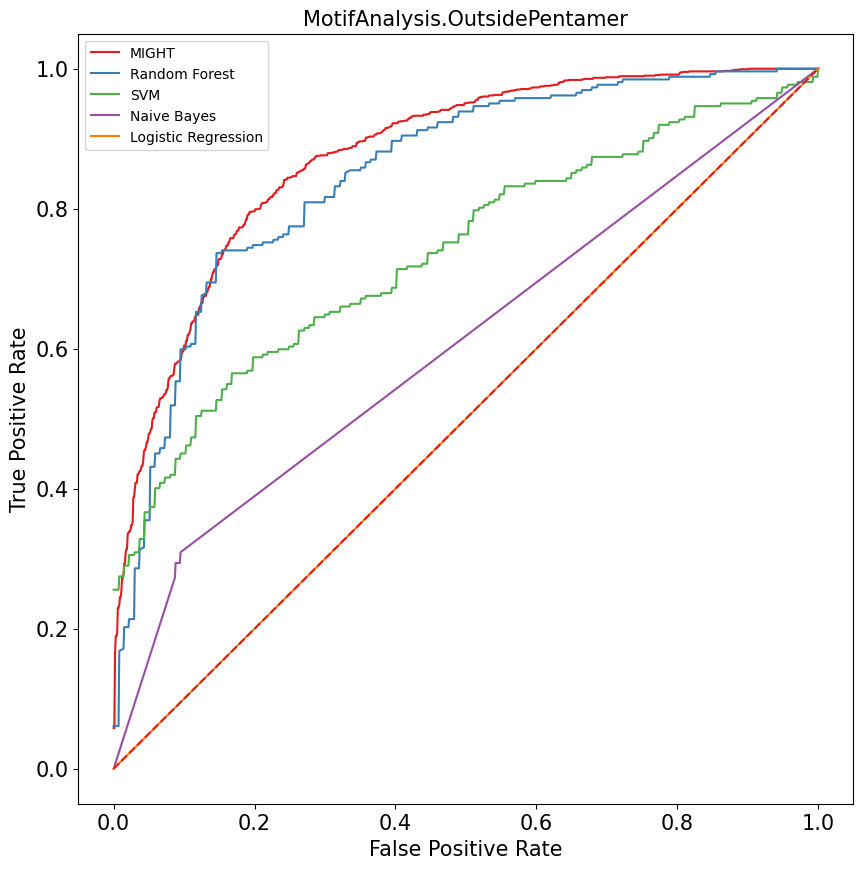

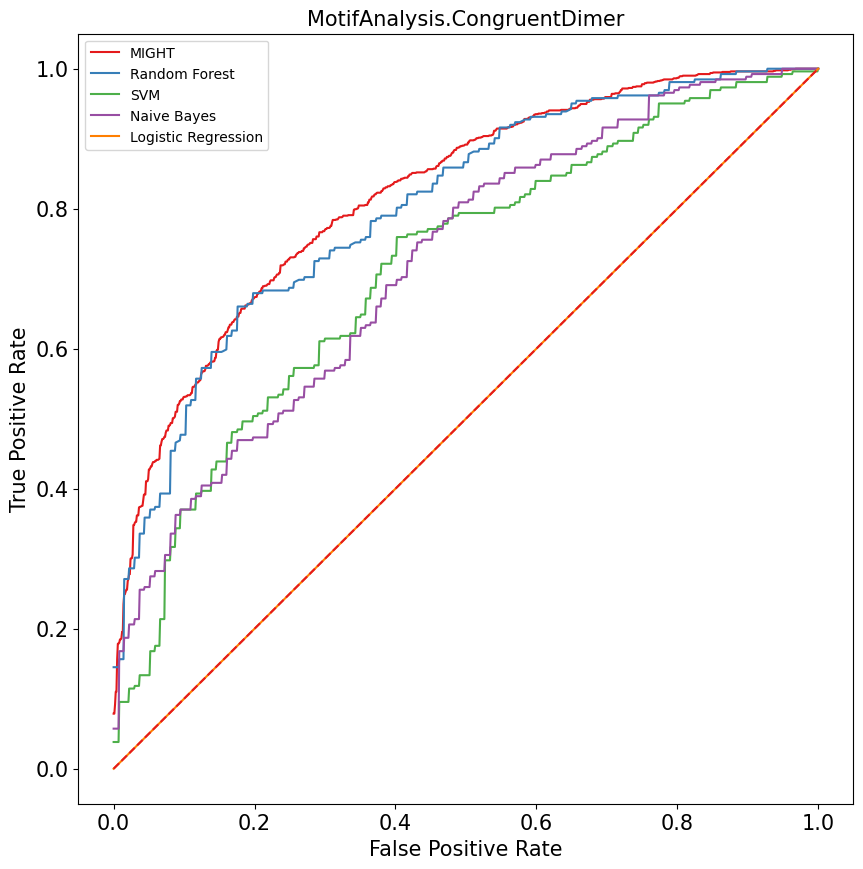

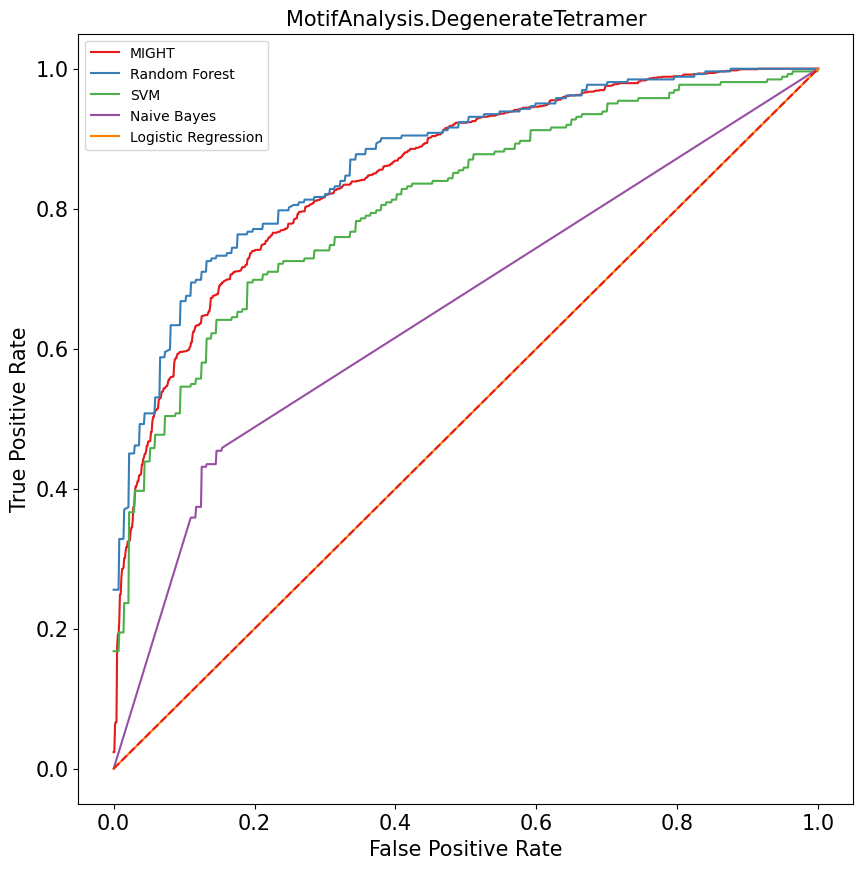

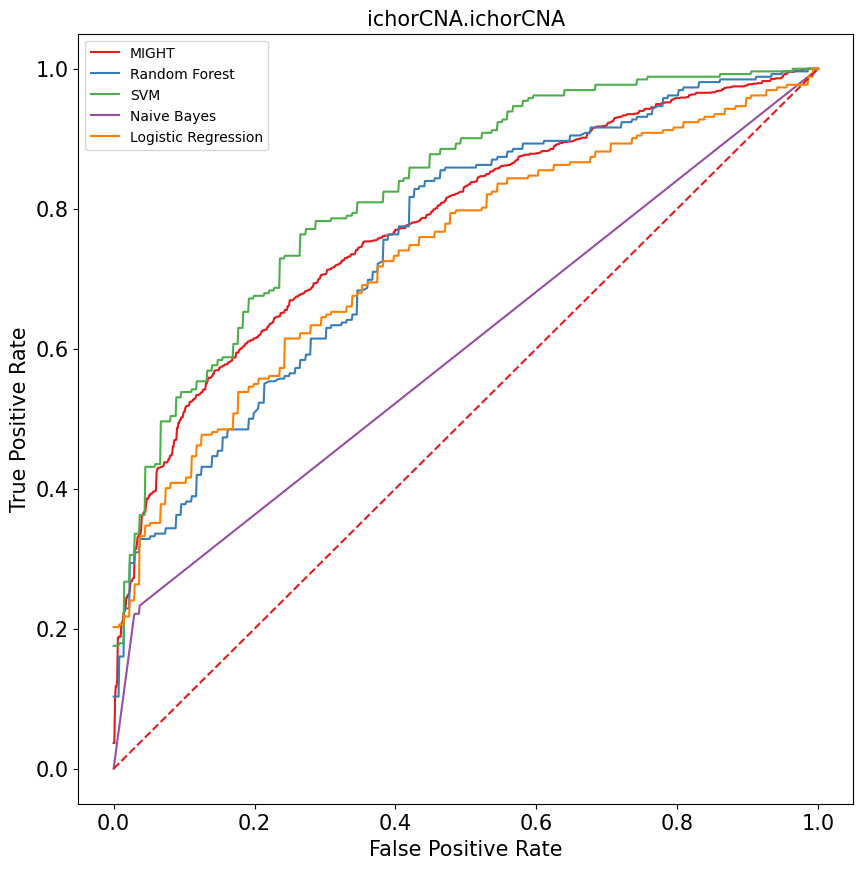

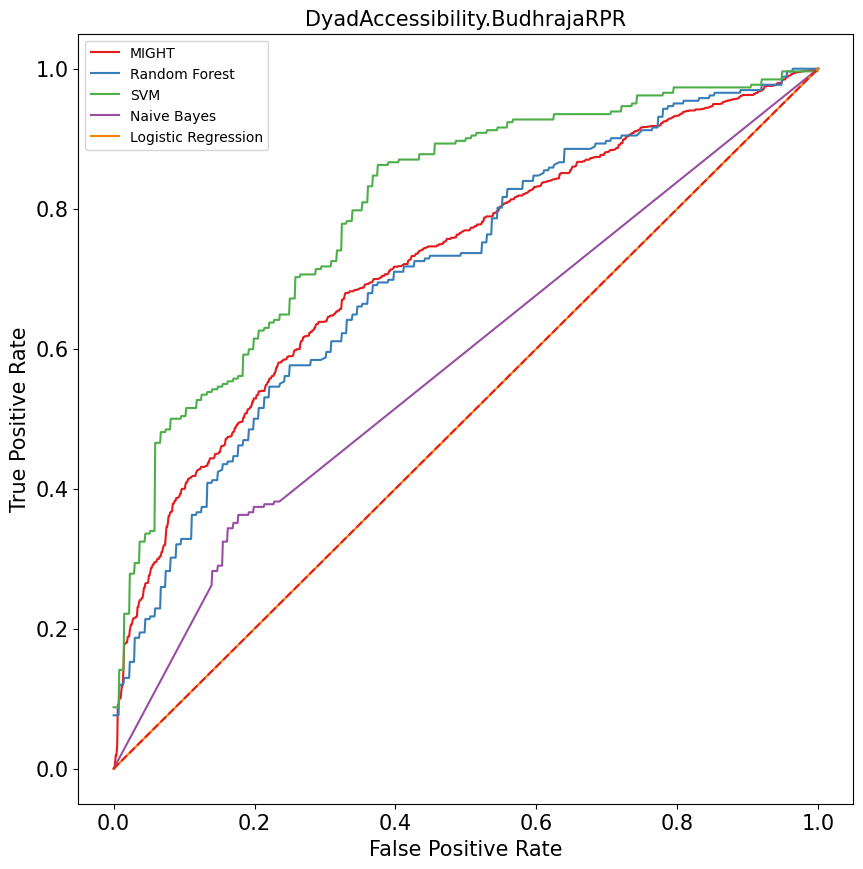

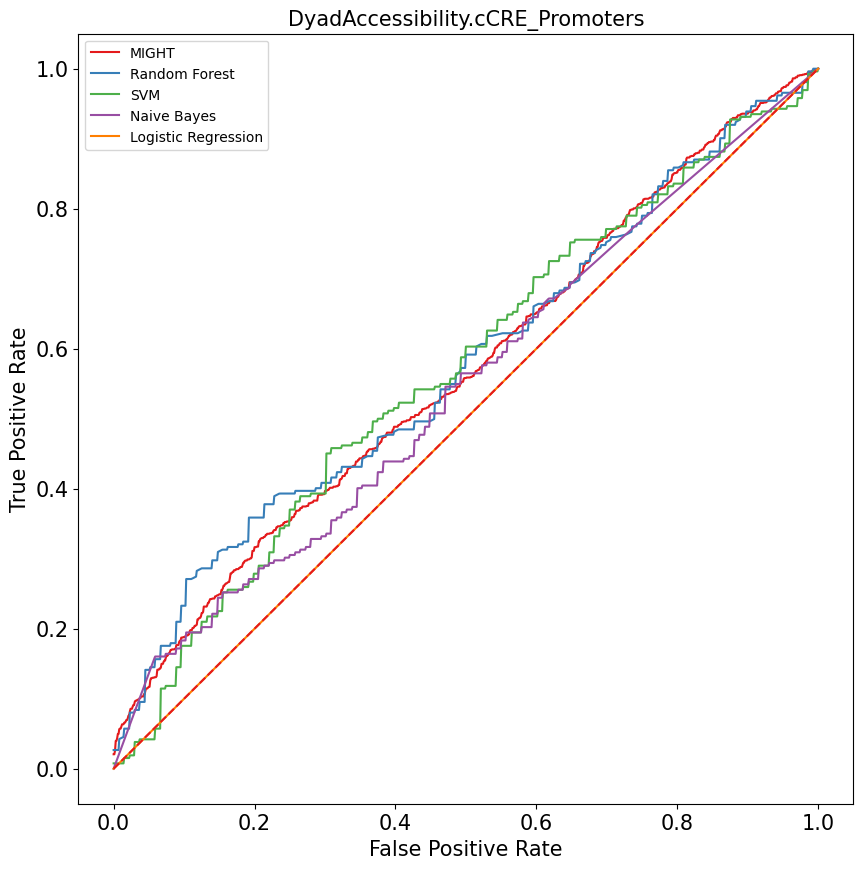

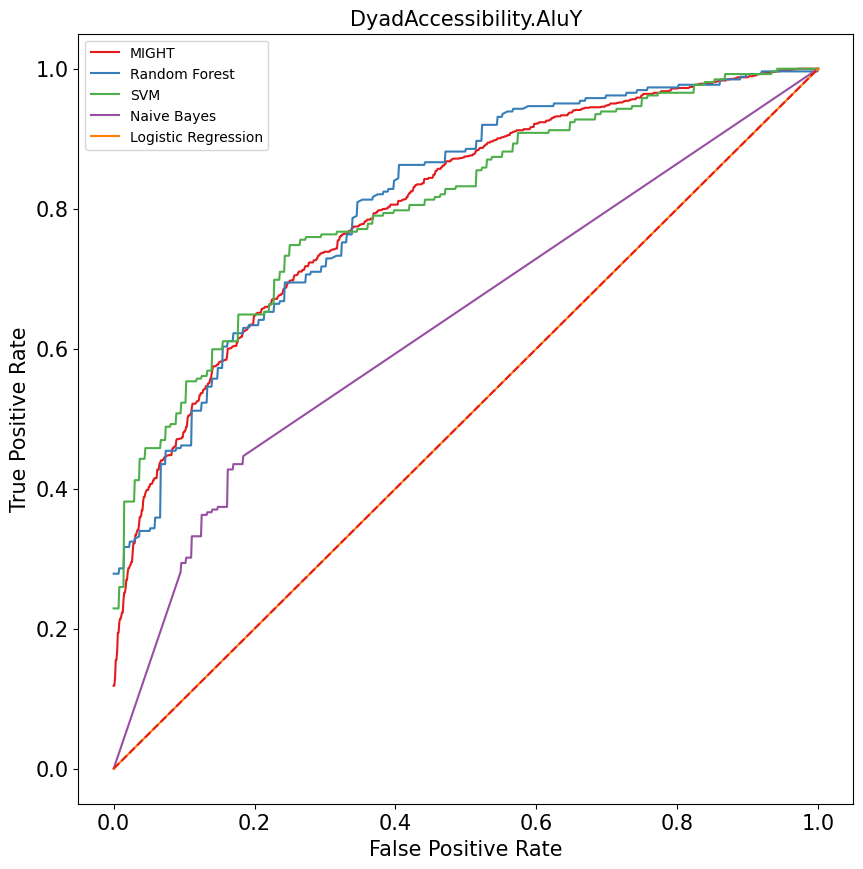

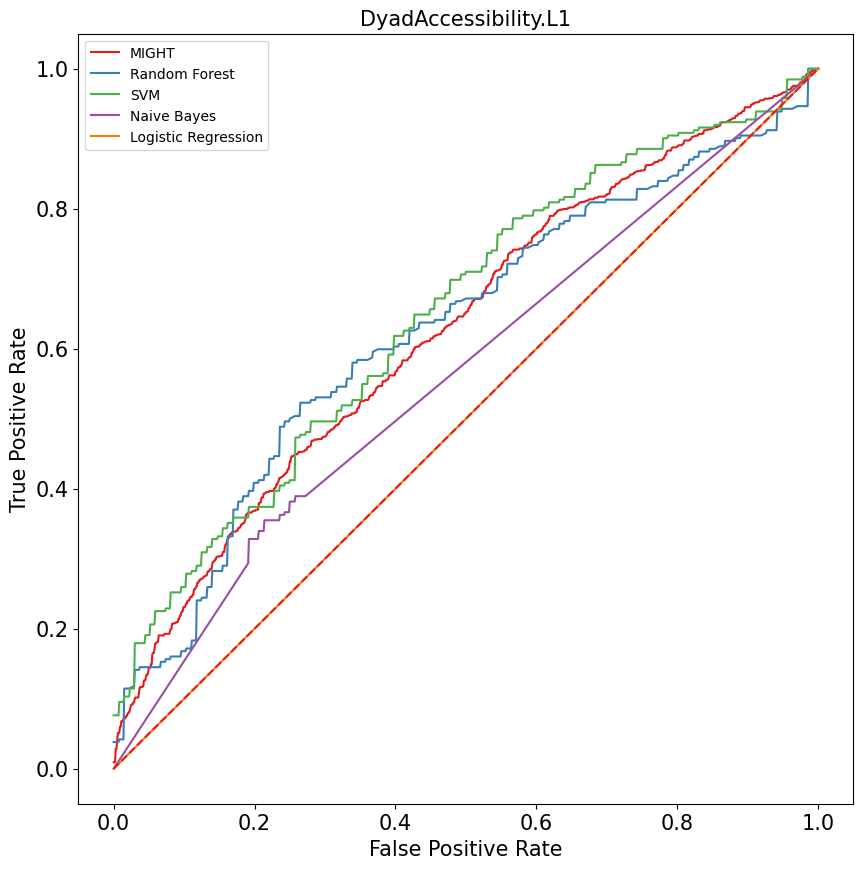

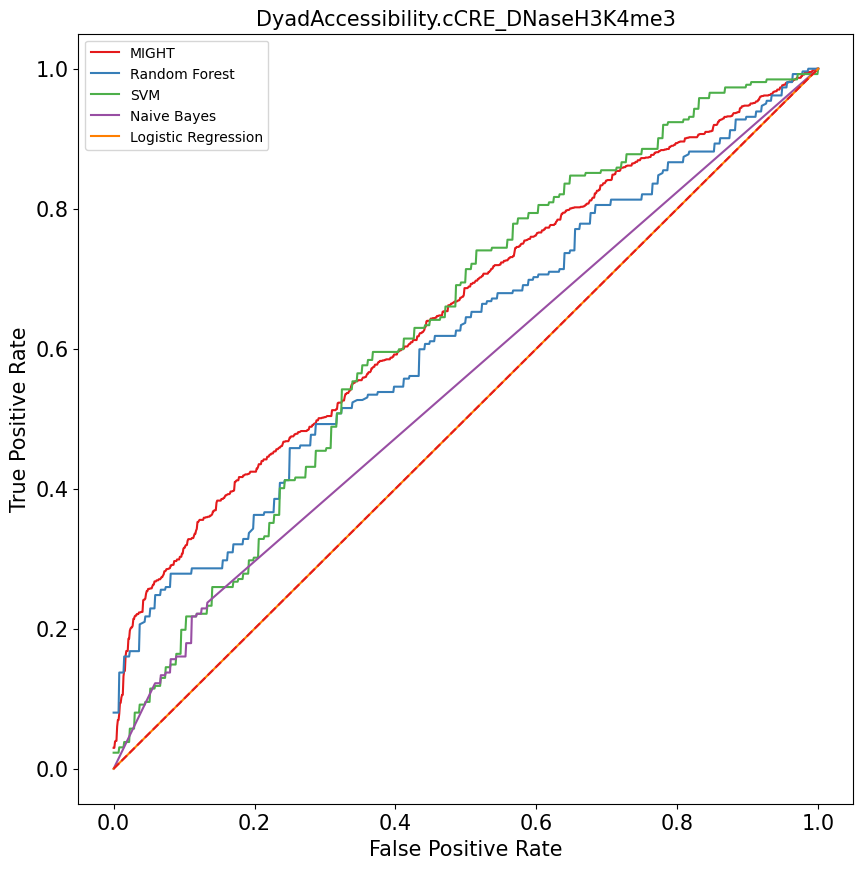

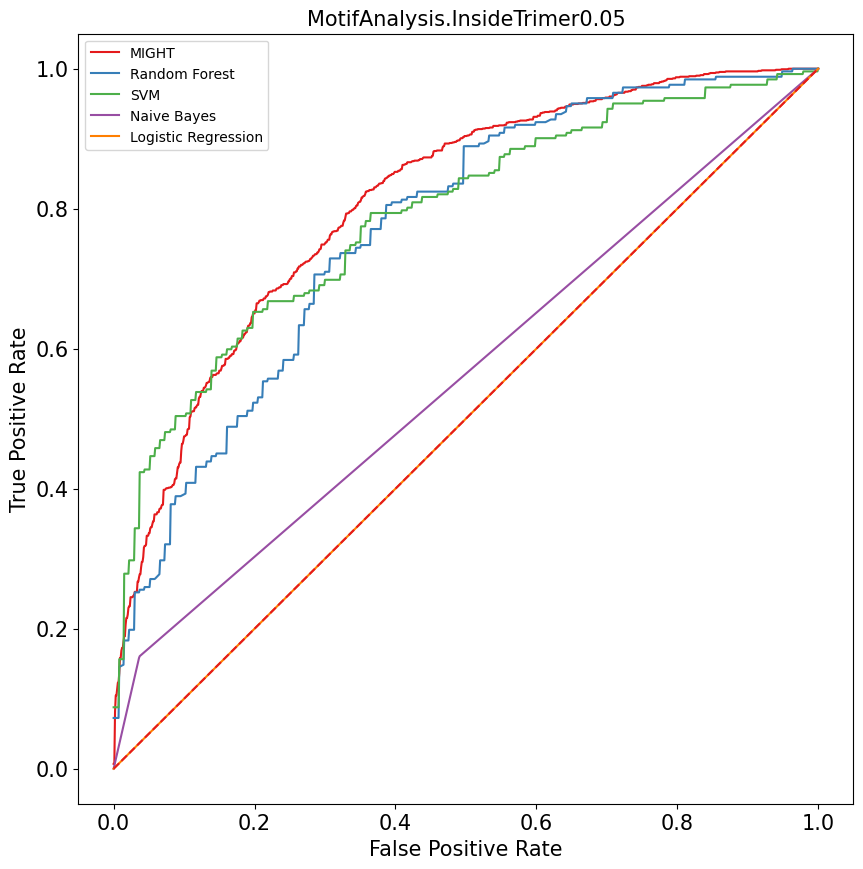

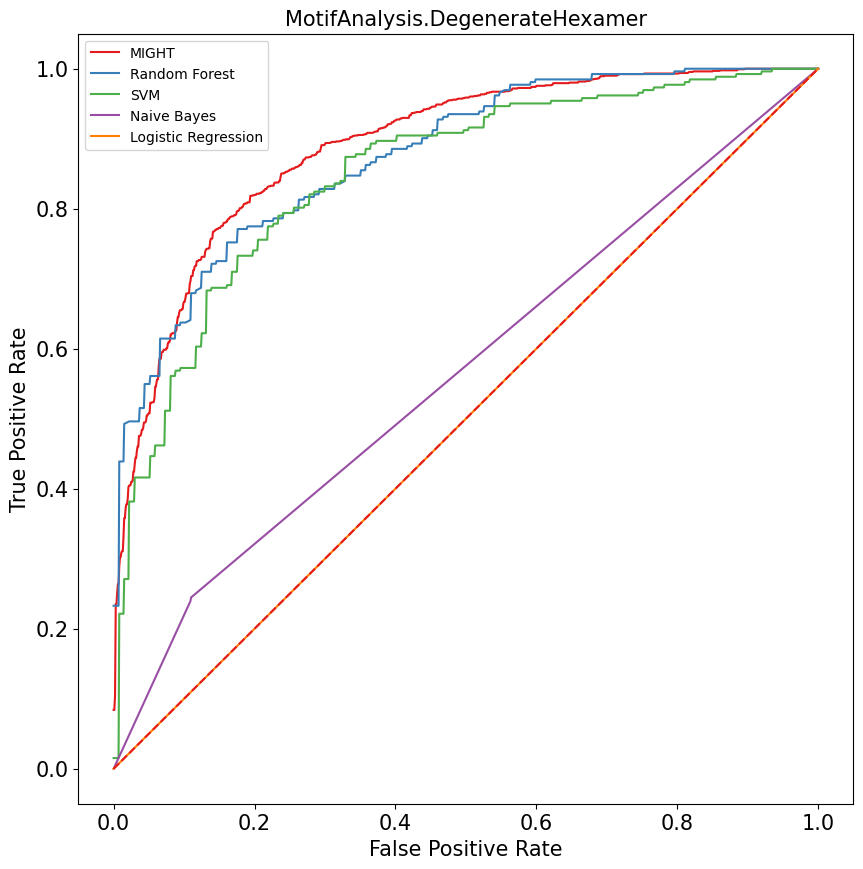

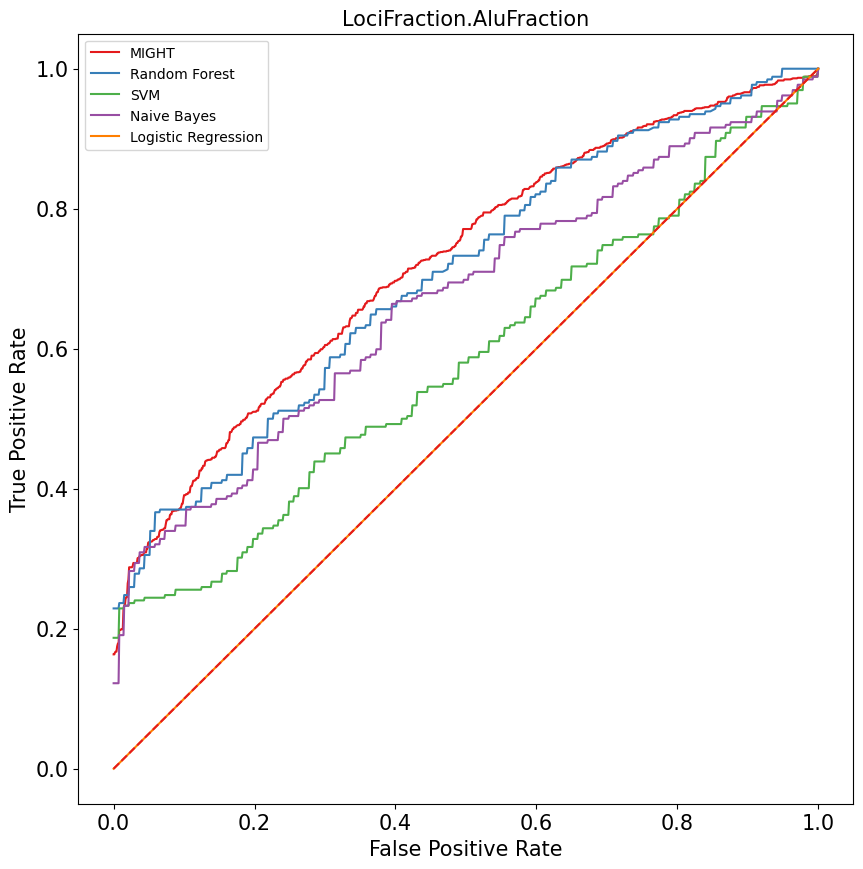

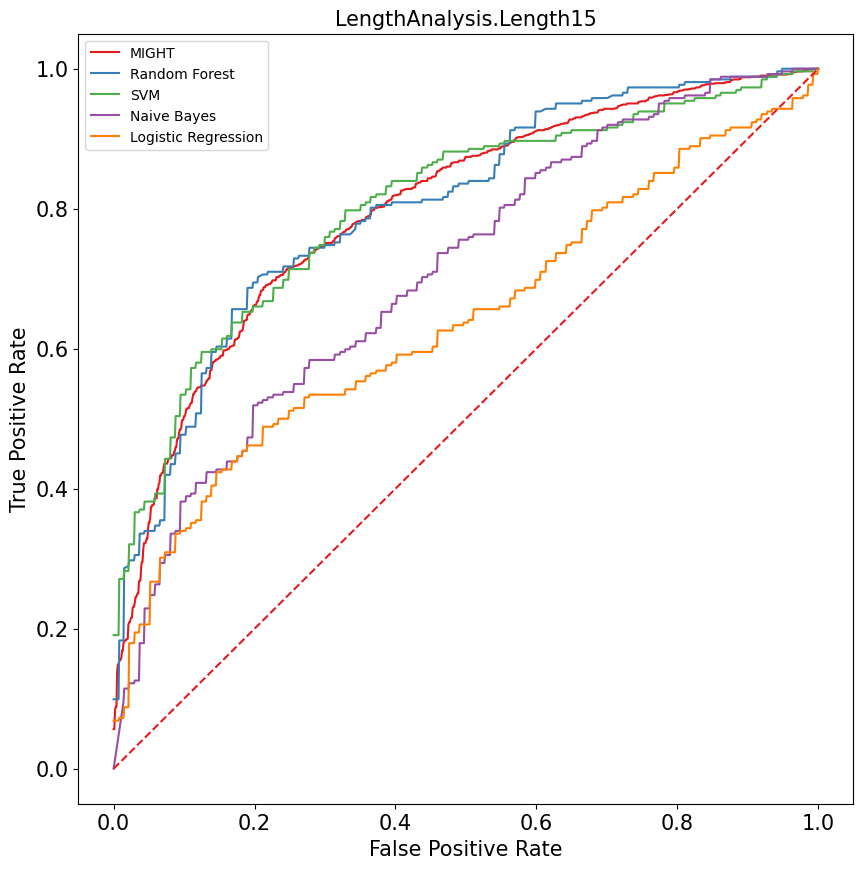

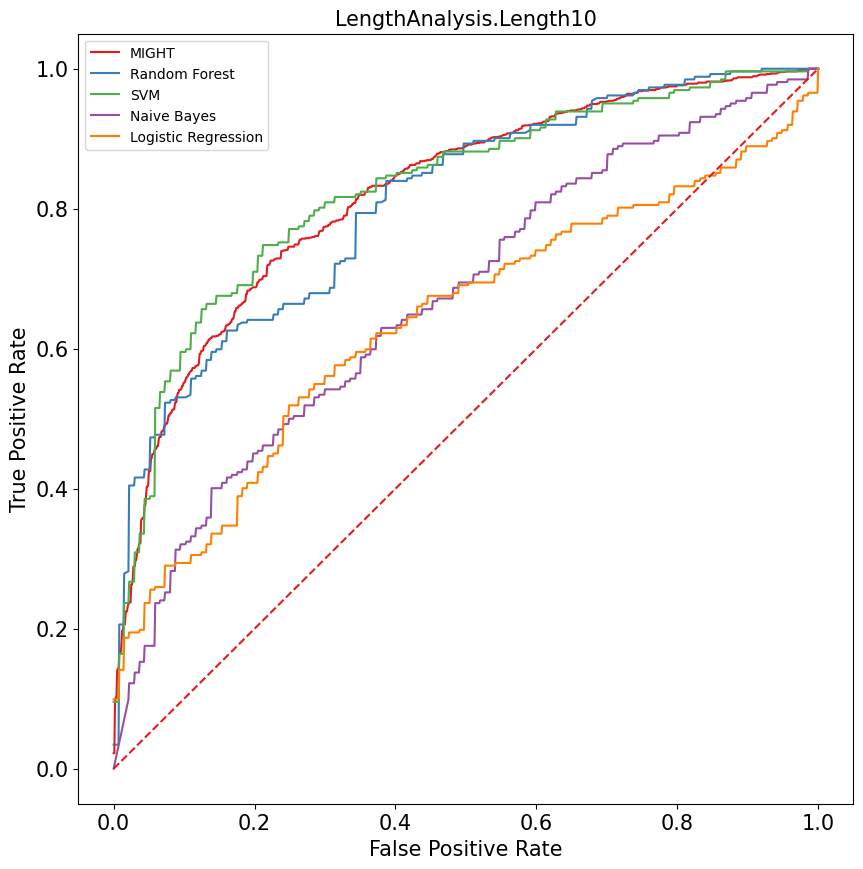

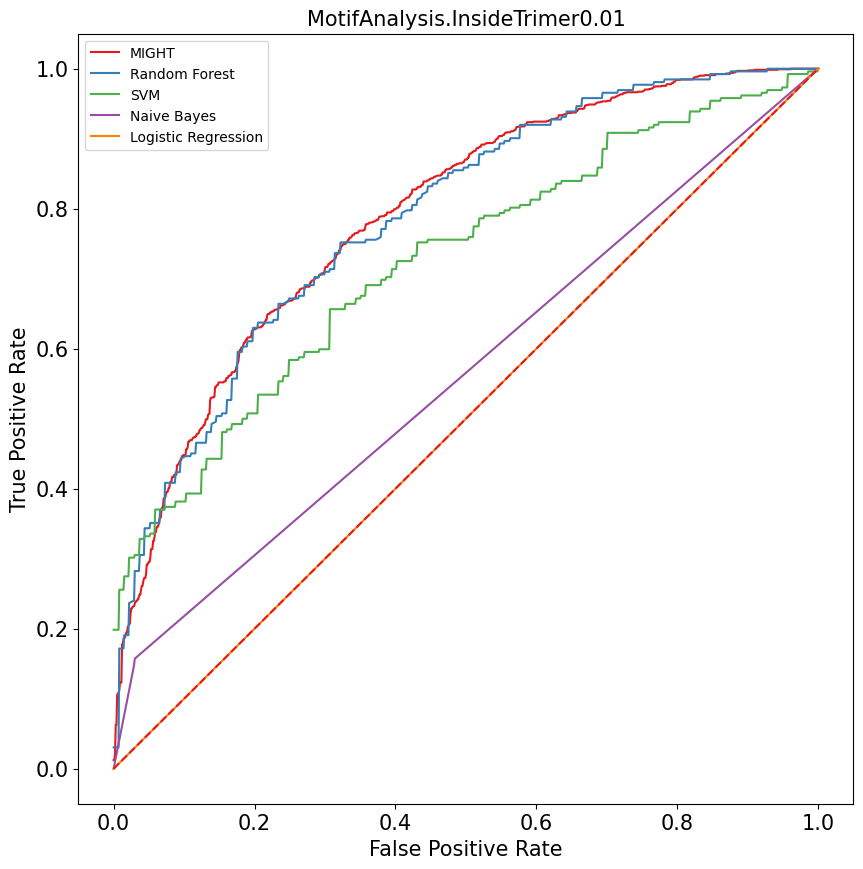

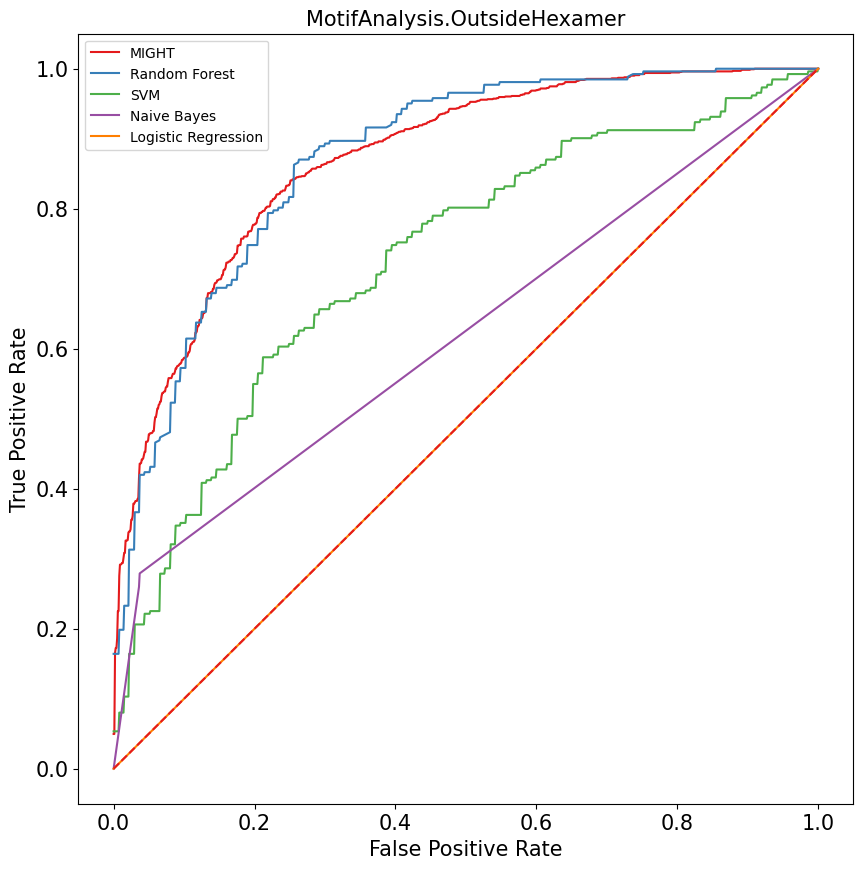

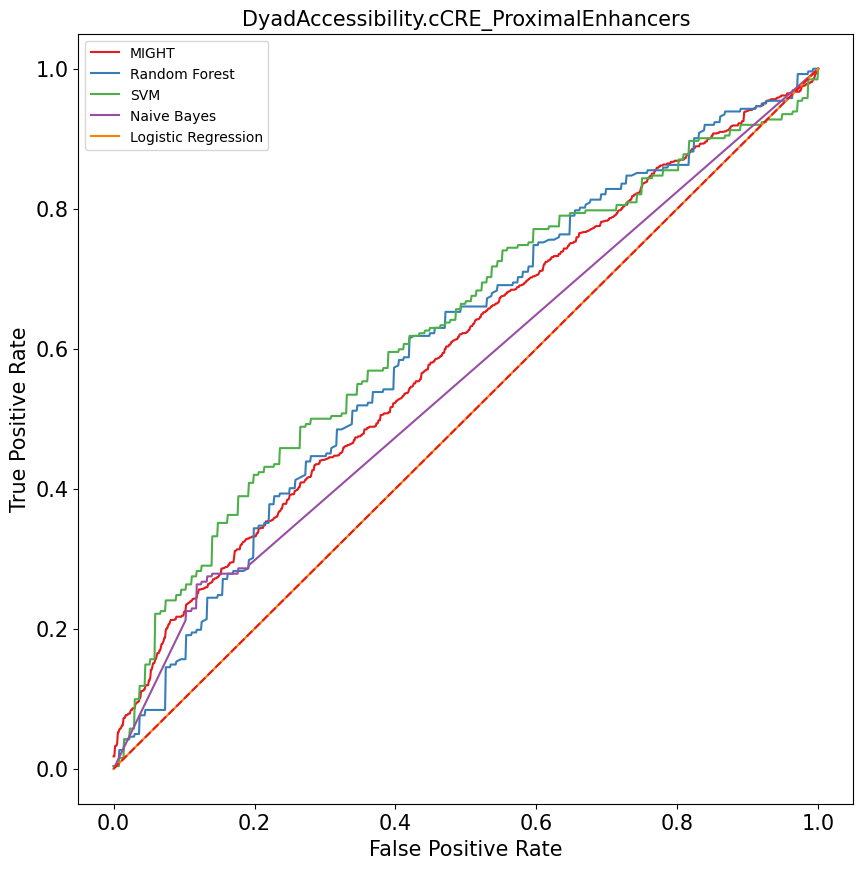

In [106]:
import matplotlib.pyplot as plt

FIG_DIR = "./results/figures/"
clf_name = [
    "MIGHT",
    "Random Forest",
    "SVM",
    "Naive Bayes",
    "Logistic Regression",
]
n_clf = len(clf_name)
i, j = 0, 2
# plot the ROC curve
base_fpr = np.linspace(0, 1, 1001)
N_ITR = 7
fpr_ls = np.zeros((N_ITR, n_clf, 1001))
tpr_ls = np.zeros((N_ITR, n_clf, 1001))
feature_mean_s = []
for i in range(len(filelist)):
    FEATURENAME = filelist[i].split(".csv")[0]
    print(FEATURENAME)
    # initialize a figure
    fig, ax = plt.subplots(figsize=(10, 10))
    for j in range(n_clf):
        tpr_s = []
        for k in range(N_ITR):
            tpr = np.interp(base_fpr, fprs[i][j], tprs[i][j])
            tpr_s.append(tpr)
        ax.plot(base_fpr, np.mean(tpr_s, axis=0), label=clf_name[j])
    plt.legend(fontsize=10)
    ax.plot([0,1], [0,1], "--")
    ax.set_xlabel("False Positive Rate", fontsize=15)
    ax.set_ylabel("True Positive Rate", fontsize=15)
    ax.tick_params(axis="both", labelsize=15)
    plt.title(f"{FEATURENAME}", fontsize=15)
    plt.savefig(FIG_DIR + "roc_" + str(FEATURENAME) + ".png", dpi=120)
    

# Plot the TPR and FPR of each models as strip plots

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

FIG_DIR = "./results/figures/"
clf_name = [
    "MIGHT",
    "Random Forest",
    "SVM",
    "Naive Bayes",
    "Logistic Regression",
]
n_clf = len(clf_name)
base_fpr = np.linspace(0, 1, 1001)
max_fpr = 0.02
# create a dataframe to store the results
results = pd.DataFrame()
for i in range(len(filelist)):
    FEATURENAME = filelist[i].split(".csv")[0]
    print(i, FEATURENAME)
    for j in range(n_clf):
        tpr = np.interp(base_fpr, fprs[i][j], tprs[i][j])
        # print(tpr)
        tpr_mean = np.mean(tpr, axis=0)
        tpr_std = np.std(tpr, axis=0)
        sa98 = max([tpr for (base_fpr, tpr) in zip(base_fpr, tpr) if base_fpr <= max_fpr])
        print( " "*5, j+1, clf_name[j])
        print(" "*10, "sa98:", sa98)
        print(" "*10, "tpr:", tpr_mean)
        # add the results to the dataframe
        row = {
            "Feature": FEATURENAME,
            "Classifier": clf_name[j],
            "sa98": sa98,
            "tpr": tpr_mean,
        }
        results = results._append(row, ignore_index=True)
        


0 Delfi.LengthRatio
      1 MIGHT
           sa98: 0.07774390243902439
           tpr: 0.6186945676274945
      2 Random Forest
           sa98: 0.07984790874524715
           tpr: 0.6378841234810817
      3 SVM
           sa98: 0.2813688212927757
           tpr: 0.7754450872321595
      4 Naive Bayes
           sa98: 0.03472026072786529
           tpr: 0.5355039246467818
      5 Logistic Regression
           sa98: 0.07604562737642585
           tpr: 0.5193399756137399
1 MotifAnalysis.OutsideTrimer
      1 MIGHT
           sa98: 0.233587786259542
           tpr: 0.8407073842188346
      2 Random Forest
           sa98: 0.42748091603053434
           tpr: 0.8676395474754254
      3 SVM
           sa98: 0.1297709923664122
           tpr: 0.718922299074971
      4 Naive Bayes
           sa98: 0.17557251908396945
           tpr: 0.716515719465991
      5 Logistic Regression
           sa98: 0.02
           tpr: 0.5
2 MotifAnalysis.OutsideDimer
      1 MIGHT
           sa98: 0.201526717557

In [68]:
display(results)

,Feature,Classifier,sa98,tpr
0,Delfi.LengthRatio,MIGHT,0.077744,0.618695
1,Delfi.LengthRatio,Random Forest,0.079848,0.637884
2,Delfi.LengthRatio,SVM,0.281369,0.775445
3,Delfi.LengthRatio,Naive Bayes,0.034720,0.535504
4,Delfi.LengthRatio,Logistic Regression,0.076046,0.519340
...,...,...,...,...
215,DyadAccessibility.cCRE_ProximalEnhancers,MIGHT,0.077217,0.596769
216,DyadAccessibility.cCRE_ProximalEnhancers,Random Forest,0.053435,0.547165
217,DyadAccessibility.cCRE_ProximalEnhancers,SVM,0.022901,0.567947
218,DyadAccessibility.cCRE_ProximalEnhancers,Naive Bayes,0.056358,0.609686


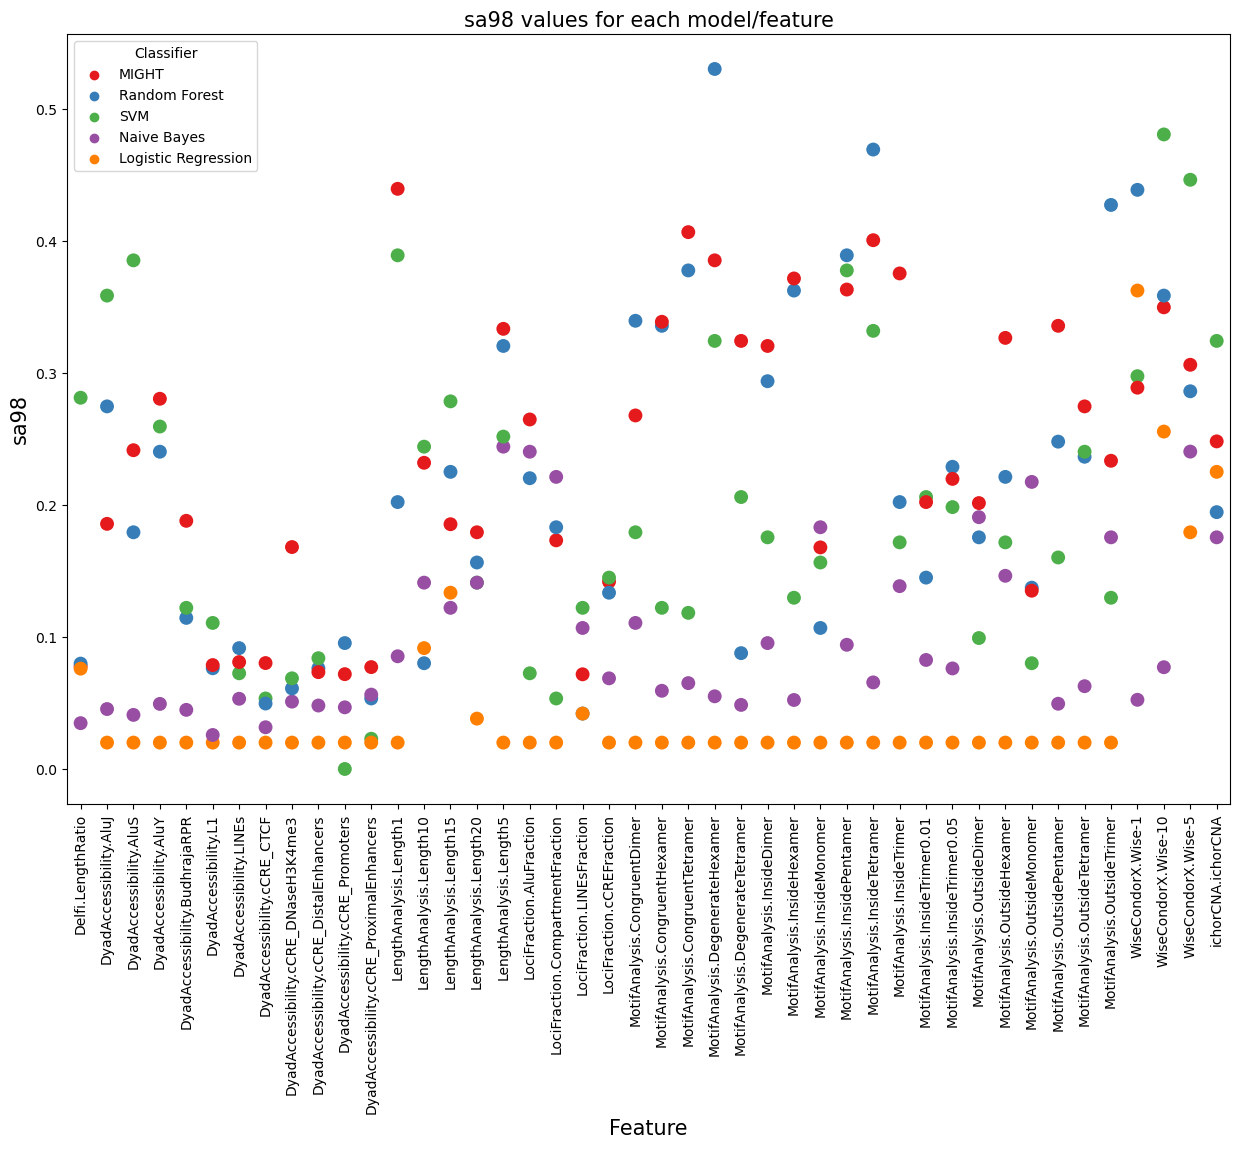

In [94]:
# plot as a stripplot with the sa98 values for each feature
plt.figure(figsize=(15, 10))
# sort the results by the feature name
# results = results.sort_values("Feature")
# change the hues so the "MIGHT" is red, "Random Forest" is blue, "SVM" is green, "Naive Bayes" is orange, and "Logistic Regression" is purple
sns.set_palette(sns.color_palette("Set1", 5))
sns.stripplot(x="Feature", y="sa98", hue="Classifier", data=results.sort_values("Feature"), jitter=False, dodge=False, size=10)
plt.xticks(rotation=90)
plt.xlabel("Feature", fontsize=15)
plt.ylabel("sa98", fontsize=15)
plt.title("sa98 values for each model/feature", fontsize=15)
# save the plot
plt.savefig(FIG_DIR + "cancer44_sa98_stripplot.png", dpi=120)



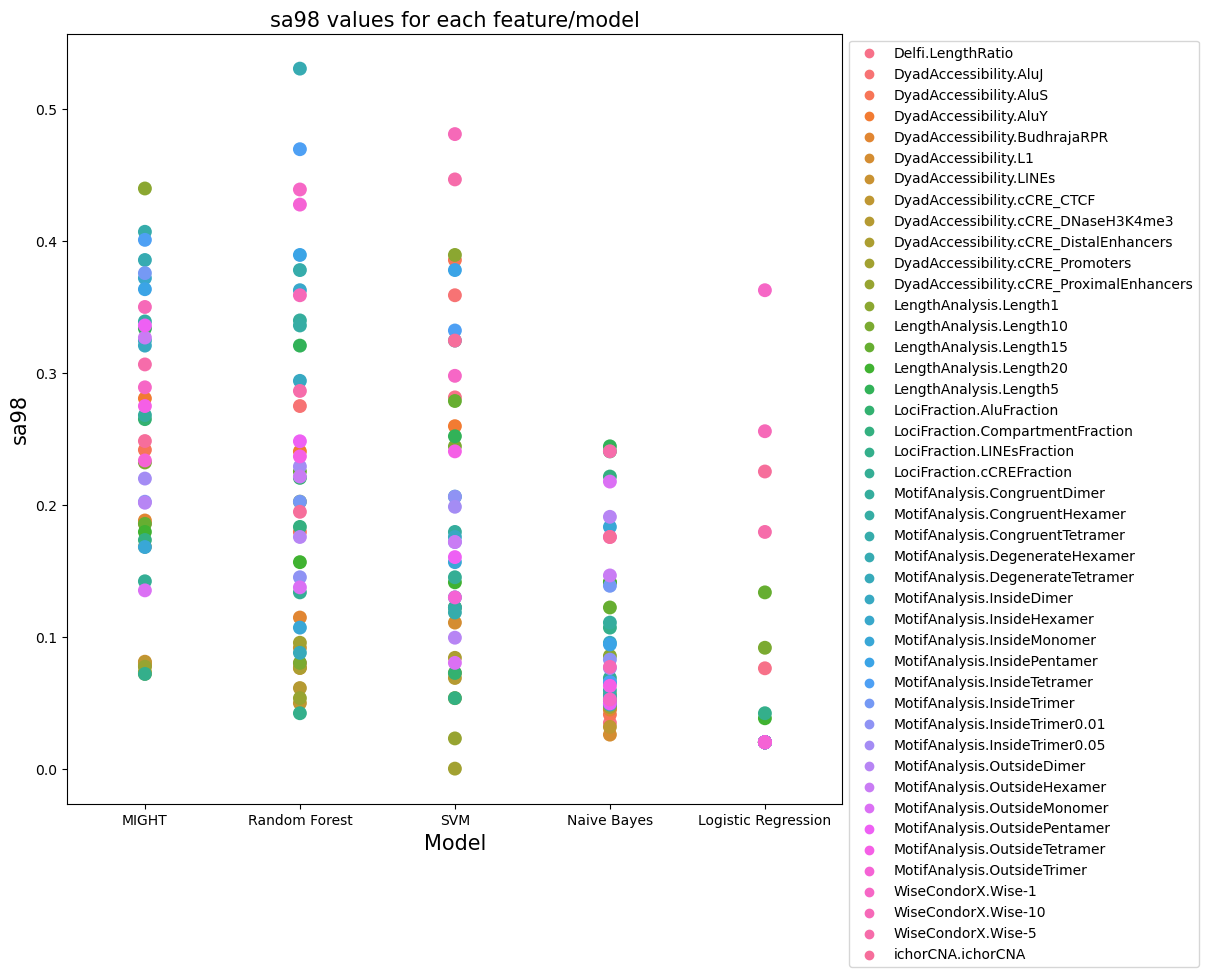

In [95]:
# plot as a stripplot with the sa98 values for each feature
plt.figure(figsize=(10, 10))
# sort the results by the feature name
# results = results.sort_values("Feature")
# change the hues so the "MIGHT" is red, "Random Forest" is blue, "SVM" is green, "Naive Bayes" is orange, and "Logistic Regression" is purple
sns.set_palette(sns.color_palette("Set1", 5))
sns.stripplot(x="Classifier", y="sa98", hue="Feature", data=results.sort_values("Feature"), jitter=False, dodge=False, size=10)
# plt.xticks(rotation=90)
plt.xlabel("Model", fontsize=15)
plt.ylabel("sa98", fontsize=15)
plt.title("sa98 values for each feature/model", fontsize=15)
# move the legend outside the plot
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
# save the plot
plt.savefig(FIG_DIR + "cancer44_sa98_stripplot_per_model.png", dpi=120)

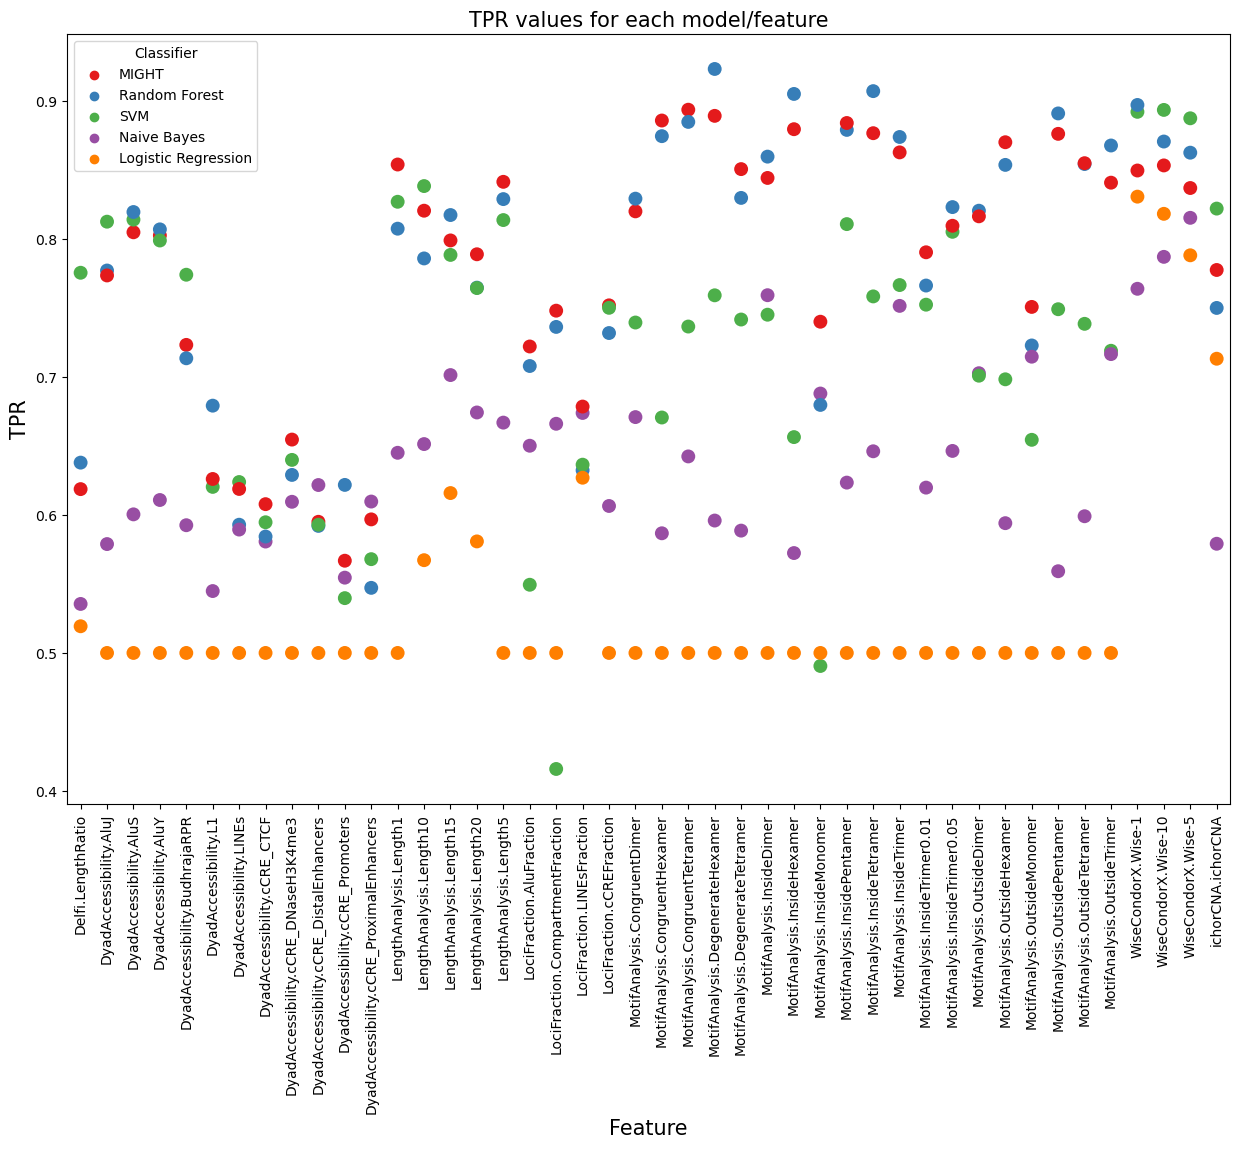

In [92]:
# plot as a stripplot with the sa98 values for each feature
plt.figure(figsize=(15, 10))
# change the hues so the "MIGHT" is red, "Random Forest" is blue, "SVM" is green, "Naive Bayes" is orange, and "Logistic Regression" is purple
sns.set_palette(sns.color_palette("Set1", 5))
sns.stripplot(x="Feature", y="tpr", hue="Classifier", data=results.sort_values("Feature"), jitter=False, dodge=False, size=10)
plt.xticks(rotation=90)
plt.xlabel("Feature", fontsize=15)
plt.ylabel("TPR", fontsize=15)
plt.title("TPR values for each model/feature", fontsize=15)
# save the plot
plt.savefig(FIG_DIR + "cancer44_tpr_stripplot.png", dpi=120)

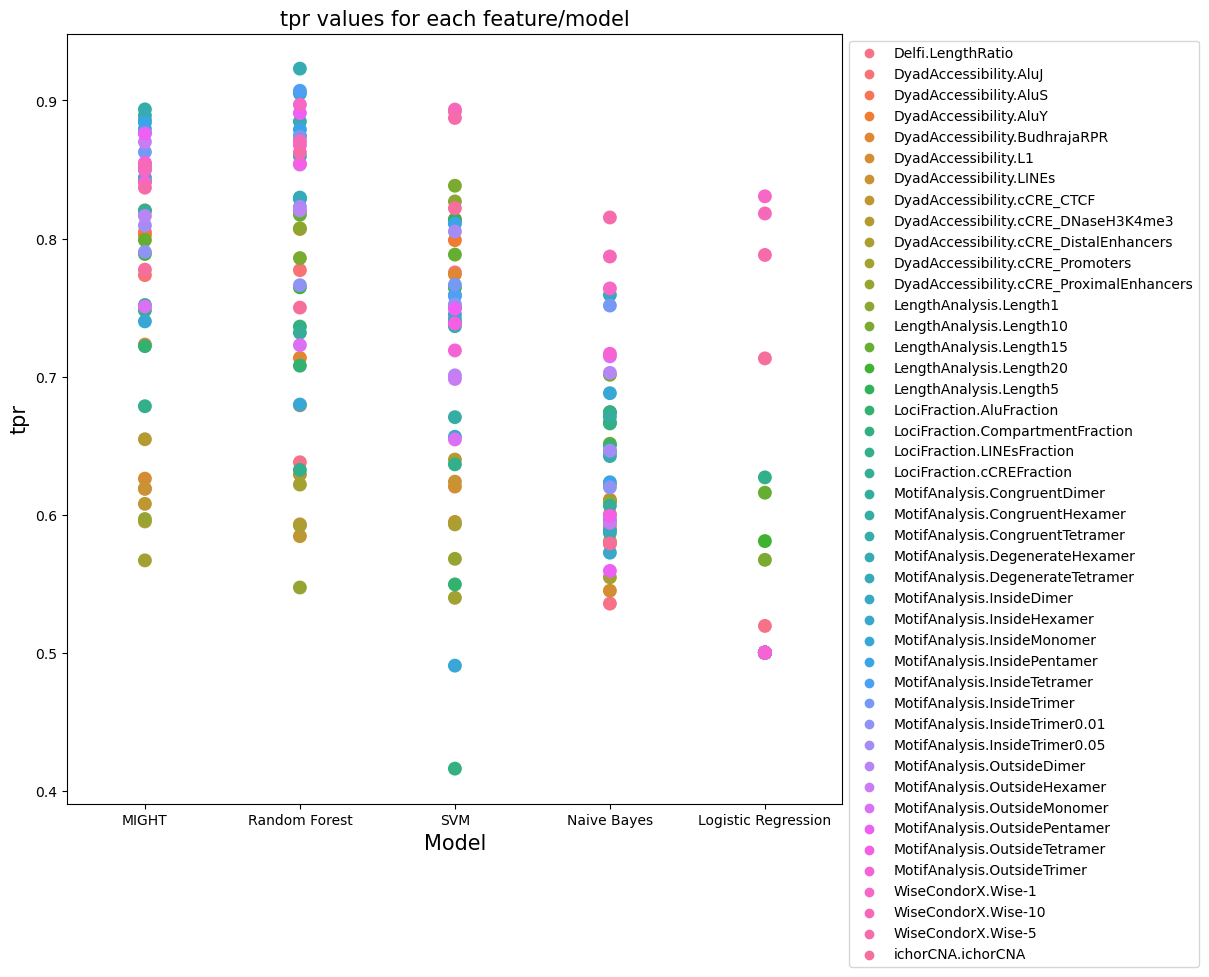

In [93]:
# plot as a stripplot with the sa98 values for each feature
plt.figure(figsize=(10, 10))
# sort the results by the feature name
# results = results.sort_values("Feature")
# change the hues so the "MIGHT" is red, "Random Forest" is blue, "SVM" is green, "Naive Bayes" is orange, and "Logistic Regression" is purple
sns.set_palette(sns.color_palette("Set1", 5))
sns.stripplot(x="Classifier", y="tpr", hue="Feature", data=results.sort_values("Feature"), jitter=False, dodge=False, size=10)
# plt.xticks(rotation=90)
plt.xlabel("Model", fontsize=15)
plt.ylabel("tpr", fontsize=15)
plt.title("tpr values for each feature/model", fontsize=15)
# move the legend outside the plot
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
# save the plot
plt.savefig(FIG_DIR + "cancer44_tpr_stripplot_per_model.png", dpi=120)